# Researcher: [Molderon](https://github.com/Molderon)
# Machine - Puritan Bennett 840 <br>
> - Contains origanic waveform bio-signals form artificial ling augmentation. <br>
> - Singal timestamp = 50hz | .csv contains ~350h of continuous pressure and flow readings. <br>
> - Data is streamed via 5 individual patients, identity is non-reconstructable.  <br>
> - Operative Mode: invecive
# Source
> University of California Davis Medical Center | [link](https://health.ucdavis.edu/medical-center/) <br>

In [ ]:
#--<Python Standard Libs>--
import time, warnings, joblib
import sys, os, subprocess
from dataclasses import dataclass, field
from typing import List, Tuple

# --<DataScience>--
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from scipy.spatial import ConvexHull, QhullError
from scipy.fft import rfft
from scipy.spatial.qhull import QhullError
from scipy.fft import fft

from pandas.plotting import scatter_matrix
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

# --<Feature Engineering>--
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.interpolate import interp1d
from scipy.interpolate import BSpline, splrep


# --<Machine Learning>--
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
assert sys.version_info >= (3, 5)
# --<Plotting Style>--
from scipy import signal
plt.style.use('dark_background')
csfont = {'fontname':'Comic Sans MS'}
hfont = {'fontname':'Helvetica'}

# --<Static Parameters>--
time_step: float = 0.02


# --<ignore>--
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)
warnings.filterwarnings("ignore")

In [56]:
def Import_Dataset(ds_name: str, trunk_target: bool) -> pd.DataFrame:
    dataset = pd.read_csv(ds_name)
    if trunk_target:
        dataset = dataset.drop(['Target_Class_0', 'Target_Class_1', 'Target_Class_2',
                                'Target_Class_3', 'Target_Class_4'], axis=1)
        dataset.info()
    return dataset

# Objectives
> - 1. Excract a un-supperviced dataset.
> - 2. Excract a sub-set describing geometrical properties.
> - 3. Perform Exploratory Data Analysis.

In [57]:
dataset = Import_Dataset("supperviced_PAV.csv", trunk_target= True)
dataset.to_csv("Organic_InvasivePAV.csv")
dataset = Import_Dataset("supperviced_PAV.csv", trunk_target= False)
dataset.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7775200 entries, 0 to 7775199
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Breath_ID  int64  
 1   Time_Step  int64  
 2   Flow       float64
 3   Pressure   float64
dtypes: float64(2), int64(2)
memory usage: 237.3 MB


,Breath_ID,Time_Step,Flow,Pressure,Target_Class_0,Target_Class_1,Target_Class_2,Target_Class_3,Target_Class_4
0,0,0,2.24,5.14,0,1,0,0,0
1,0,1,7.75,5.26,0,1,0,0,0
2,0,2,29.54,6.54,0,1,0,0,0
3,0,3,52.12,9.79,0,1,0,0,0
4,0,4,71.78,18.38,0,1,0,0,0


### Volume Calculation from Flow

Volume ($V$) is the integral of Flow ($\dot{V}$) over time ($t$).

$$V(t) = \int_{0}^{t} \dot{V}(\tau) d\tau$$

For discrete data with a constant time step ($\Delta t$), the volume at the $k^{th}$ point ($V_k$) is calculated as:

$$V_k = \left( \sum_{i=1}^{k} \dot{V}_i \right) \cdot \Delta t$$

In [58]:
def Terraform_DataSet(group: pd.DataFrame, time_step: float):
    features = {}
    Breath_ID = group['Breath_ID'].iloc[0]
    
    Flow, Pressure = "Flow", "Pressure"
    
    mask = group[[Flow, Pressure]].notna().all(axis=1)
    valid_group = group.loc[mask].reset_index(drop=True)
    
    if len(valid_group) < 2:
        return pd.DataFrame([features]).assign(Breath_ID=Breath_ID)
    
    Flow_array = valid_group[Flow].to_numpy() 
    P = valid_group[Pressure].to_numpy()

    # 1. Volume Calculation (Flow Integration using 0.02s step)
    # Volume (TV) is the cumulative integral of Flow over time.
    TV_cumsum = np.cumsum(Flow_array) * time_step
    
    # Standardize Volume: set the lowest point (EEV) to 0.
    TV_min_actual = TV_cumsum.min()
    TV = TV_cumsum - TV_min_actual 
    
    
    # --- Geometrical Feature Extraction ---
    
    # 2. Area (Work of Breathing)
    features["Polynomial_Area"] = np.abs(np.trapz(P, TV))
    
    # 3. Convex Hull Area
    if len(TV) >= 3:
        try:
            hull = ConvexHull(np.column_stack((TV, P)))
            features["Hull_Area"] = hull.volume
        except QhullError:
            features["Hull_Area"] = 0.0
    else:
        features["Hull_Area"] = 0.0
    
    # 4. Signal Frequency (FFT)
    for name, arr in [('TV', TV), ('P', P)]:
        ft = np.abs(rfft(arr))[:3]
        for i, val in enumerate(ft, 1):
            features[f"ft_{name}_{i}"] = val
    
    # 5. Extremes, Perimeter, Centroid, and Ranges
    diffs = np.diff(np.column_stack((TV, P)), axis=0)
    
    # Missing Feature: Extremes
    features["TV_Max"] = TV.max()   
    features["TV_Min"] = TV.min()   
    features["P_Max"] = P.max()     
    features["P_Min"] = P.min()     
    
    # Standard Range Features
    features.update({
        "Perimeter": np.sum(np.hypot(diffs[:, 0], diffs[:, 1])),
        "Width_TV_Range": np.ptp(TV),    # Tidal Volume (TV) Range
        "Height_P_Range": np.ptp(P),    # Driving Pressure (P_Max - P_Min)
        "Centroid_X_TV": TV.mean(),
        "Centroid_Y_P": P.mean(),
    })
    
    # Missing Feature: Compliance and Ratio
    P_range = features["Height_P_Range"]
    TV_range = features["Width_TV_Range"]
    
    # Dynamic Compliance (Volume Range / Pressure Range)
    features["Dynamic_Compliance"] = TV_range / P_range if P_range != 0 else 0.0
    # Aspect Ratio (Height / Width)
    features["Aspect_Ratio_H_W"] = P_range / TV_range if TV_range != 0 else 0.0
    
    # 6. Curvature Calculation
    dx = np.gradient(TV)
    dy = np.gradient(P)
    ddx, ddy = np.gradient(dx), np.gradient(dy)
    with np.errstate(divide='ignore', invalid='ignore'):
        curvature_val = np.nanmean(np.abs(dx*ddy - dy*ddx) / (dx**2 + dy**2)**1.5)
    features["Curvature"] = curvature_val if not np.isnan(curvature_val) else 0.0

    return pd.DataFrame([features]).assign(Breath_ID=Breath_ID)


def Feature_Extracting(df: pd.DataFrame) -> pd.DataFrame:
    # Pass the determined time step (0.02s) to the data transformation function
    features = pd.concat(
        [Terraform_DataSet(g, time_step) for _, g in df.groupby('Breath_ID', sort=False)],
        ignore_index=True
    )
    return df.merge(features, on='Breath_ID', how='left')

In [59]:
dataset = Feature_Extracting(dataset)
dataset = dataset.groupby('Breath_ID', as_index=False).first()
dataset = dataset.drop(dataset.columns[0: 9], axis=1)
dataset.head()

,Polynomial_Area,Hull_Area,ft_TV_1,ft_TV_2,ft_TV_3,ft_P_1,ft_P_2,ft_P_3,TV_Max,TV_Min,P_Max,P_Min,Perimeter,Width_TV_Range,Height_P_Range,Centroid_X_TV,Centroid_Y_P,Dynamic_Compliance,Aspect_Ratio_H_W,Curvature
0,288.263816,416.287927,2748.4692,973.509451,928.099112,1899.96,1841.156762,1676.559079,20.8014,0.0,35.11,0.0,109.729958,20.8014,35.11,3.435586,2.374950,0.592464,1.687867,3.759296
1,314.842590,463.600906,1534.3324,1365.291616,1245.807707,2120.11,1999.562790,1679.614704,21.7208,0.0,36.81,0.0,139.813347,21.7208,36.81,1.917915,2.650138,0.590079,1.694689,17.825141
2,400.419550,565.091637,4166.4914,1169.804444,1085.448002,2144.02,2024.941064,1708.075785,24.8204,0.0,35.00,0.0,164.485692,24.8204,35.00,5.208114,2.680025,0.709154,1.410130,4.326186
3,57.091896,132.275174,4277.3100,6.439823,7.082924,502.00,501.532220,500.130836,9.0620,0.0,40.01,0.0,85.336416,9.0620,40.01,5.346637,0.627500,0.226493,4.415140,2.060282
4,293.877274,408.863963,7552.4034,351.454876,348.554987,1771.67,1734.037718,1626.197496,19.2414,0.0,36.23,0.0,123.345407,19.2414,36.23,9.440504,2.214587,0.531090,1.882919,2.221511


In [60]:
features = dataset.columns
features

Index(['Polynomial_Area', 'Hull_Area', 'ft_TV_1', 'ft_TV_2', 'ft_TV_3',
       'ft_P_1', 'ft_P_2', 'ft_P_3', 'TV_Max', 'TV_Min', 'P_Max', 'P_Min',
       'Perimeter', 'Width_TV_Range', 'Height_P_Range', 'Centroid_X_TV',
       'Centroid_Y_P', 'Dynamic_Compliance', 'Aspect_Ratio_H_W', 'Curvature'],
      dtype='object')

# Generic Pattern Recognition

In [61]:
plt.rcParams['figure.dpi'] = 100 # Adjust figure resolution for better quality
pd.set_option('display.max_columns', None) # Display all columns for describe()



# --- EDA Functions ---

def ExploreFeature(dataset: pd.DataFrame, feature_name: str):
    """
    Performs and displays summary statistics and distribution plots
    for a single numerical feature.
    """
    if feature_name not in dataset.columns:
        print(f"Error: Feature '{feature_name}' not found in DataFrame.")
        return

    print(f"\n--- Analyzing Feature: '{feature_name}' ---")

    # A. Summary Statistics
    print(f"\nSummary Statistics for '{feature_name}':")
    print(dataset[feature_name].describe())

    # B. Visualizations (Histogram & Box Plot)
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(dataset[feature_name], kde=True, bins='auto', color='skyblue')
    plt.title(f'Distribution of {feature_name}', fontsize=14)
    plt.xlabel(feature_name, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', alpha=0.75)

    plt.subplot(1, 2, 2)
    sns.boxplot(y=dataset[feature_name], color='lightcoral')
    plt.title(f'Box Plot of {feature_name}', fontsize=14)
    plt.ylabel(feature_name, fontsize=12)
    plt.grid(axis='y', alpha=0.75)

    plt.tight_layout(pad=3.0)
    plt.show()



def ScatteredCorelations(dataset: pd.DataFrame, target_feature: str, other_features: list):
    if target_feature not in dataset.columns:
        print(f"Error: Target feature '{target_feature}' not found in DataFrame.")
        return

    # Filter other_features to ensure they exist in dataset and are numerical
    valid_other_features = [f for f in other_features if f in dataset.columns and pd.api.types.is_numeric_dtype(dataset[f])]
    if not valid_other_features:
        print(f"No valid numerical 'other features' to plot against '{target_feature}'.")
        return

    # Calculate correlations and select top 3 (excluding self-correlation)
    correlations = dataset[[target_feature] + valid_other_features].corr()[target_feature].abs().sort_values(ascending=False)
    # Exclude the target_feature itself from the list
    top_correlated = correlations.drop(target_feature).index.tolist()[:3]

    if not top_correlated:
        print(f"No correlated features found for '{target_feature}' to plot scatter plots.")
        return

    print(f"\n--- Scatter Plots for '{target_feature}' vs. Top Correlated Features ---")
    num_plots = len(top_correlated)
    ncols = min(num_plots, 3) # Max 3 columns for plots
    nrows = (num_plots + ncols - 1) // ncols # Calculate rows needed

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten() # Flatten for easy iteration

    for i, feature in enumerate(top_correlated):
        sns.scatterplot(x=feature, y=target_feature, data=dataset, ax=axes[i], alpha=0.7, color='teal')
        axes[i].set_title(f'{target_feature} vs. {feature}', fontsize=12)
        axes[i].set_xlabel(feature, fontsize=10)
        axes[i].set_ylabel(target_feature, fontsize=10)
        axes[i].grid(True, linestyle='--', alpha=0.6)

    for j in range(i + 1, len(axes)): # Hide any unused subplots
        fig.delaxes(axes[j])

    plt.tight_layout(pad=3.0)
    plt.show()



def GroupedAnalysis(dataset: pd.DataFrame, primary_feature: str, grouping_feature: str, num_bins: int = 4):

    if primary_feature not in dataset.columns or grouping_feature not in dataset.columns:
        print(f"Error: One or both features ('{primary_feature}', '{grouping_feature}') not found in DataFrame.")
        return
    if not pd.api.types.is_numeric_dtype(dataset[primary_feature]) or not pd.api.types.is_numeric_dtype(dataset[grouping_feature]):
        print(f"Error: Both '{primary_feature}' and '{grouping_feature}' must be numerical for this analysis.")
        return

    print(f"\n--- Grouped Analysis: '{primary_feature}' by Bins of '{grouping_feature}' ---")

    # Create bins for the grouping feature
    grouping_col_binned_name = f'{grouping_feature}_Binned_Q{num_bins}'
    try:
        dataset[grouping_col_binned_name] = pd.qcut(dataset[grouping_feature], q=num_bins, duplicates='drop',
                                                     labels=[f'Q{i+1}' for i in range(num_bins) if i < dataset[grouping_feature].nunique()])
    except Exception as e:
        print(f"Could not create bins for '{grouping_feature}'. Error: {e}")
        print(f"Unique values in '{grouping_feature}': {dataset[grouping_feature].nunique()}")
        print("Skipping grouped analysis for this pair.")
        return

    # Filter out any NaN groups that might result from qcut if data distribution is problematic
    filtered_df = dataset.dropna(subset=[grouping_col_binned_name]).copy()
    if filtered_df.empty:
        print(f"No valid data points after binning '{grouping_feature}'. Skipping grouped analysis.")
        return

    # Summary statistics of primary_feature by grouping_feature bins
    print(f"\nSummary Statistics of '{primary_feature}' by '{grouping_feature}' Bins:")
    print(filtered_df.groupby(grouping_col_binned_name)[primary_feature].describe())

    # Box plot
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=grouping_col_binned_name, y=primary_feature, data=filtered_df, palette='viridis')
    plt.title(f'{primary_feature} Distribution by {grouping_feature} Groups', fontsize=14)
    plt.xlabel(f'{grouping_feature} Quantile Groups', fontsize=12)
    plt.ylabel(primary_feature, fontsize=12)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Violin plot (provides more detail on distribution shape)
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=grouping_col_binned_name, y=primary_feature, data=filtered_df, palette='plasma')
    plt.title(f'{primary_feature} Distribution (Violin Plot) by {grouping_feature} Groups', fontsize=14)
    plt.xlabel(f'{grouping_feature} Quantile Groups', fontsize=12)
    plt.ylabel(primary_feature, fontsize=12)
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Clean up the temporary binned column
    dataset.drop(columns=[grouping_col_binned_name], inplace=True, errors='ignore')

In [62]:
def EDA(dataset: pd.DataFrame, features: list = None, corr_threshold: float = 0.5, filter_corr_tresh: bool = True) -> pd.DataFrame:    
    if features is None:
        features = dataset.columns.tolist()
    
    Pure_dataframe = pd.DataFrame()    
    print("\nCorrelation Matrix of All Features:")
    correlation_matrix = dataset[features].corr()
    print(correlation_matrix)

    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, annot_kws={"size": 10})
    plt.title('Correlation Matrix of All Features', fontsize=16)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.show()
    
    if filter_corr_tresh:
        strong_corr_features = set()
        
        for col in correlation_matrix.columns:
            high_corr_mask = (correlation_matrix[col].abs() >= corr_threshold) & (correlation_matrix.index != col)
            if high_corr_mask.any():
                strong_corr_features.add(col)
        
        strong_corr_features = sorted(strong_corr_features)
        
        if strong_corr_features:
            print(f"\nFeatures with strong correlations (≥ |{corr_threshold}|): {strong_corr_features}")
            print(f"Number of strongly correlated features: {len(strong_corr_features)}")
            
            Pure_dataframe = dataset[strong_corr_features].copy()
        else:
            print(f"No strong correlations found (≥ |{corr_threshold}|)")
    
    
     # --- Loop Through Each Feature for Detailed Analysis ---
    features = Pure_dataframe.columns.tolist()
    for feature in features:
        print(f"\n\n{'='*20} DETAILED ANALYSIS FOR FEATURE: {feature} {'='*20}")

        # 1. Individual Feature Analysis (Summary & Distribution)
        ExploreFeature(dataset, feature)

        # 2. Scatter Plots against top correlated other features
        ScatterdFeatures = [f for f in features if f != feature]
        ScatteredCorelations(dataset, feature, ScatterdFeatures)

        print(f"\n--- Exploring how '{feature}' is influenced by other features (Grouped Analysis) ---")

        # Get correlations of the current 'feature' with all other features
        if feature in correlation_matrix.index:
            current_feature_correlations = correlation_matrix[feature].abs().sort_values(ascending=False)
            # Select top 2 other features (excluding itself) for grouped analysis
            top_grouping_candidates = current_feature_correlations.drop(feature, errors='ignore').index.tolist()[:2]
        else:
            top_grouping_candidates = [] # Should not happen if features is consistent

        if not top_grouping_candidates:
            print(f"No suitable grouping features found for '{feature}'.")

        for grouping_feat in top_grouping_candidates:
            GroupedAnalysis(dataset, primary_feature=feature, grouping_feature=grouping_feat, num_bins=4)

        print(f"\n{'='*20} END OF ANALYSIS FOR FEATURE: {feature} {'='*20}\n")

    print("\n\n--- All EDA Complete ---")
    
    return Pure_dataframe


Correlation Matrix of All Features:
                    Polynomial_Area  Hull_Area   ft_TV_1   ft_TV_2   ft_TV_3  \
Polynomial_Area            1.000000   0.909341  0.774586  0.524455  0.566934   
Hull_Area                  0.909341   1.000000  0.733830  0.691885  0.739429   
ft_TV_1                    0.774586   0.733830  1.000000  0.449605  0.476061   
ft_TV_2                    0.524455   0.691885  0.449605  1.000000  0.973559   
ft_TV_3                    0.566934   0.739429  0.476061  0.973559  1.000000   
ft_P_1                     0.212562   0.344648 -0.042089  0.448380  0.409210   
ft_P_2                     0.182805   0.300743 -0.089851  0.301755  0.311524   
ft_P_3                     0.124852   0.192569 -0.116403  0.010183  0.071426   
TV_Max                     0.717250   0.846786  0.700002  0.851967  0.892232   
TV_Min                          NaN        NaN       NaN       NaN       NaN   
P_Max                      0.095498   0.140983 -0.075024 -0.176176 -0.168643   
P_M

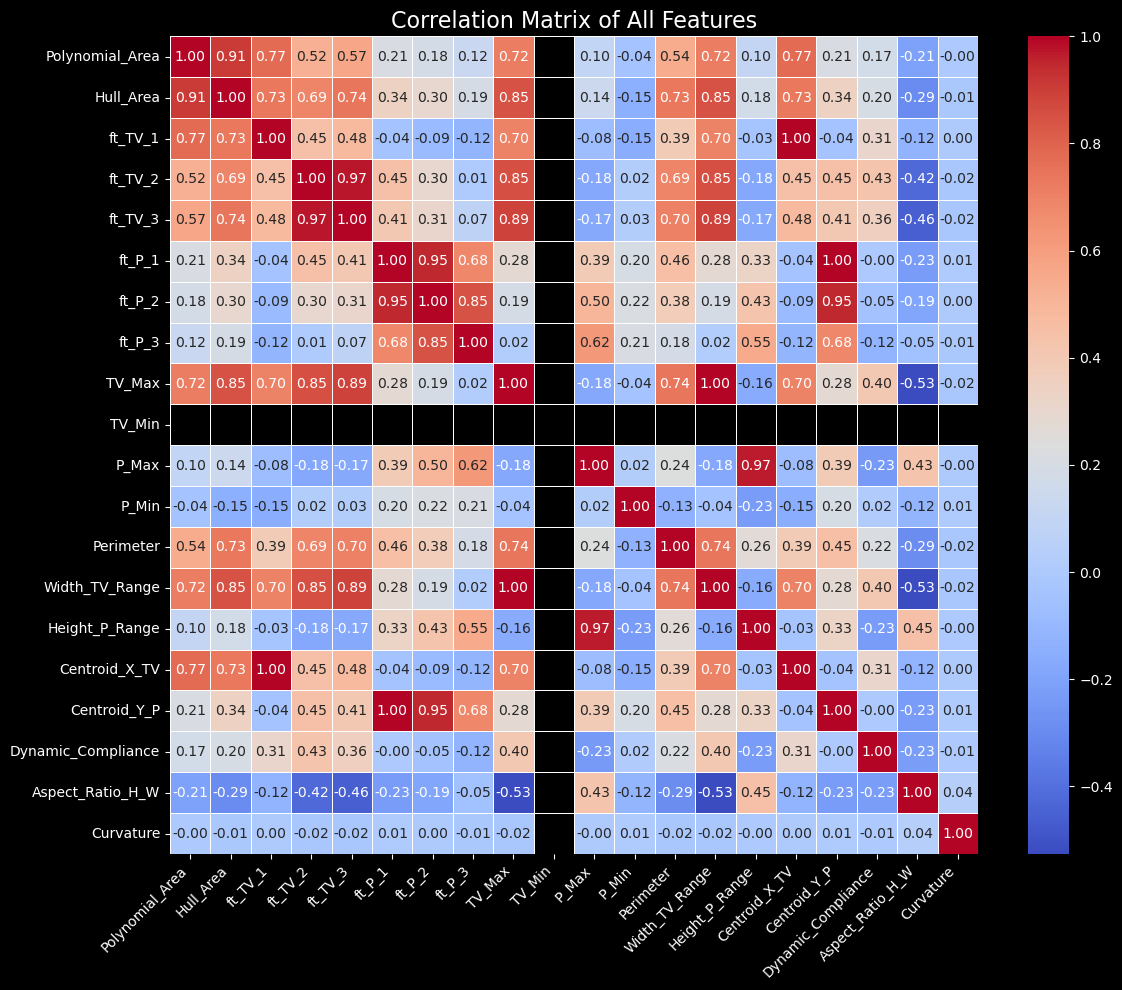


Features with strong correlations (≥ |0.5|): ['Aspect_Ratio_H_W', 'Centroid_X_TV', 'Centroid_Y_P', 'Height_P_Range', 'Hull_Area', 'P_Max', 'Perimeter', 'Polynomial_Area', 'TV_Max', 'Width_TV_Range', 'ft_P_1', 'ft_P_2', 'ft_P_3', 'ft_TV_1', 'ft_TV_2', 'ft_TV_3']
Number of strongly correlated features: 16


==================== DETAILED ANALYSIS FOR FEATURE: Aspect_Ratio_H_W ====================

--- Analyzing Feature: 'Aspect_Ratio_H_W' ---

Summary Statistics for 'Aspect_Ratio_H_W':
count    9719.000000
mean        1.224645
std         0.897749
min         0.006236
25%         0.700671
50%         1.028436
75%         1.418475
max        10.478963
Name: Aspect_Ratio_H_W, dtype: float64


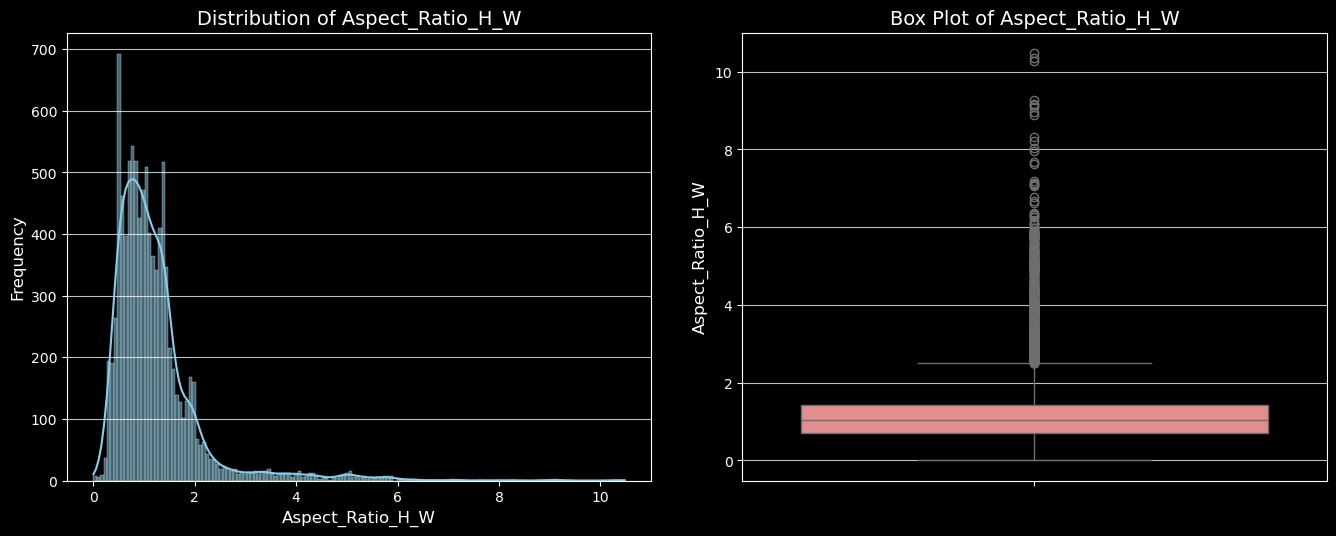


--- Scatter Plots for 'Aspect_Ratio_H_W' vs. Top Correlated Features ---


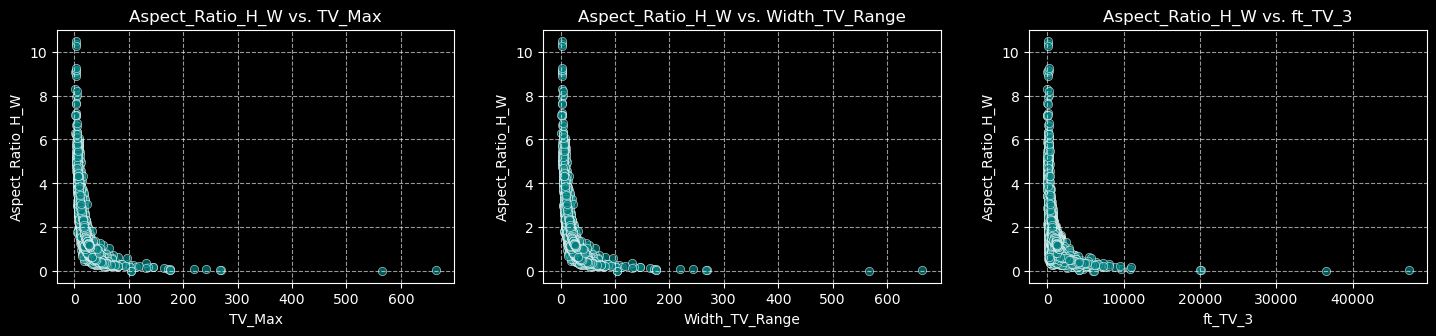


--- Exploring how 'Aspect_Ratio_H_W' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'Aspect_Ratio_H_W' by Bins of 'TV_Max' ---

Summary Statistics of 'Aspect_Ratio_H_W' by 'TV_Max' Bins:
                   count      mean       std       min       25%       50%  \
TV_Max_Binned_Q4                                                             
Q1                2430.0  2.184938  1.268297  0.462857  1.407557  1.874288   
Q2                2430.0  1.234976  0.277705  0.478048  1.048736  1.264356   
Q3                2429.0  0.873610  0.255125  0.391086  0.668567  0.863030   
Q4                2430.0  0.604912  0.208836  0.006236  0.461151  0.567664   

                       75%        max  
TV_Max_Binned_Q4                       
Q1                2.361433  10.478963  
Q2                1.413268   3.282201  
Q3                1.042906   1.871556  
Q4                0.759429   1.394924  


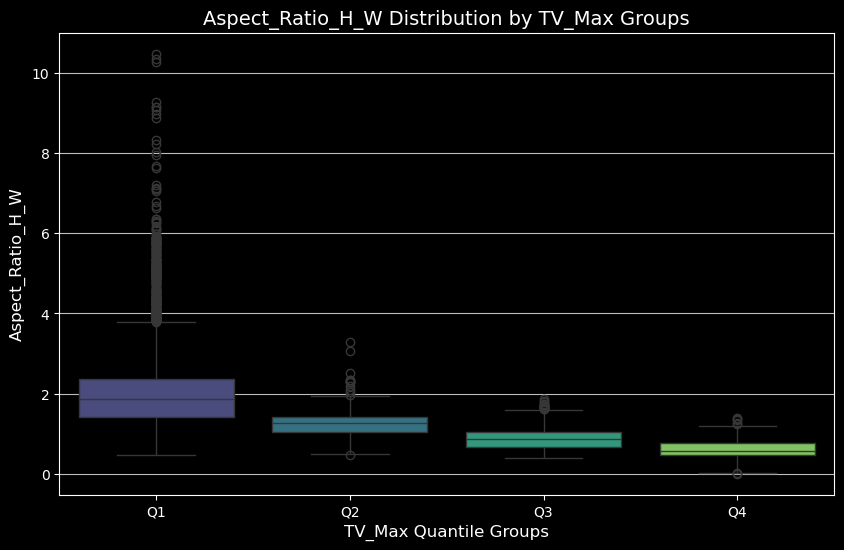

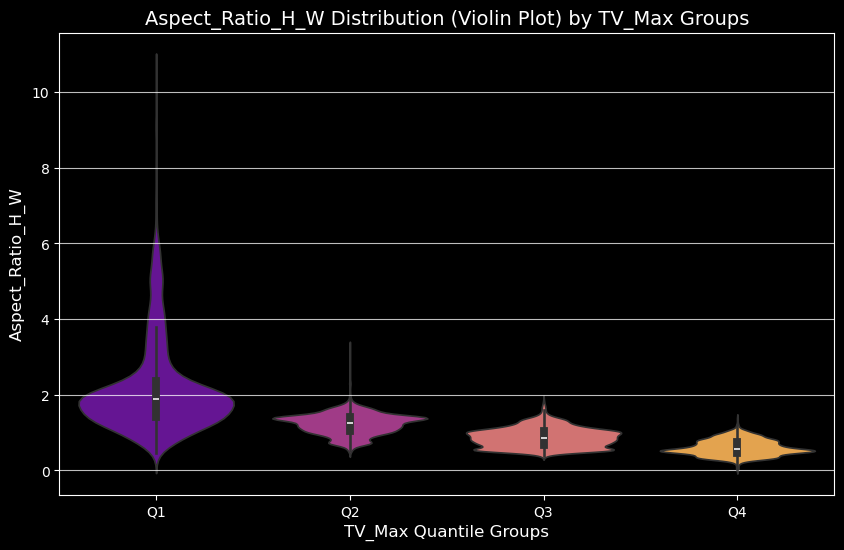


--- Grouped Analysis: 'Aspect_Ratio_H_W' by Bins of 'Width_TV_Range' ---

Summary Statistics of 'Aspect_Ratio_H_W' by 'Width_TV_Range' Bins:
                           count      mean       std       min       25%  \
Width_TV_Range_Binned_Q4                                                   
Q1                        2430.0  2.184938  1.268297  0.462857  1.407557   
Q2                        2430.0  1.234976  0.277705  0.478048  1.048736   
Q3                        2429.0  0.873610  0.255125  0.391086  0.668567   
Q4                        2430.0  0.604912  0.208836  0.006236  0.461151   

                               50%       75%        max  
Width_TV_Range_Binned_Q4                                 
Q1                        1.874288  2.361433  10.478963  
Q2                        1.264356  1.413268   3.282201  
Q3                        0.863030  1.042906   1.871556  
Q4                        0.567664  0.759429   1.394924  


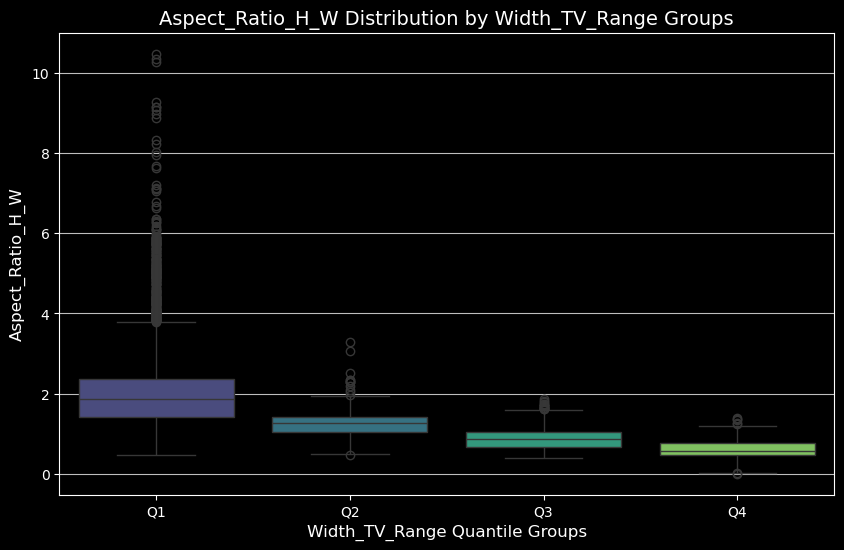

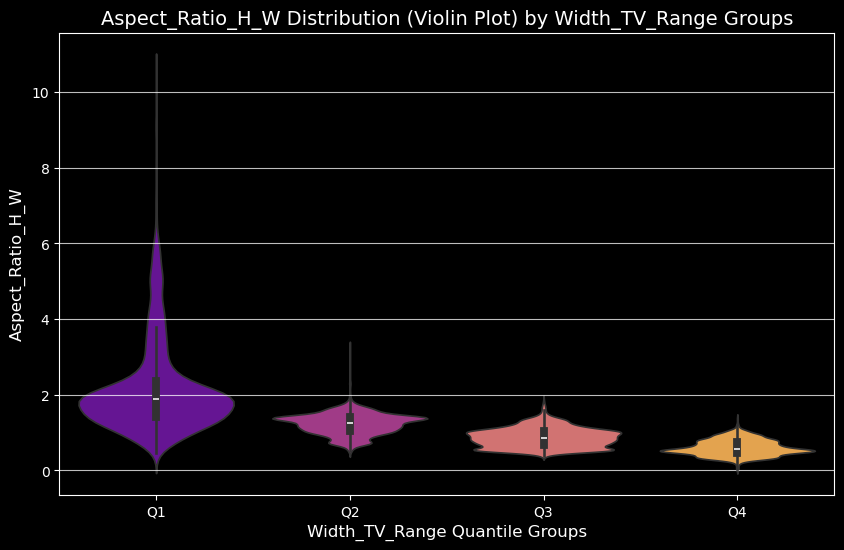


==================== END OF ANALYSIS FOR FEATURE: Aspect_Ratio_H_W ====================



==================== DETAILED ANALYSIS FOR FEATURE: Centroid_X_TV ====================

--- Analyzing Feature: 'Centroid_X_TV' ---

Summary Statistics for 'Centroid_X_TV':
count    9719.000000
mean        5.171278
std        11.722710
min         0.057796
25%         1.692527
50%         2.537409
75%         5.160354
max       578.953455
Name: Centroid_X_TV, dtype: float64


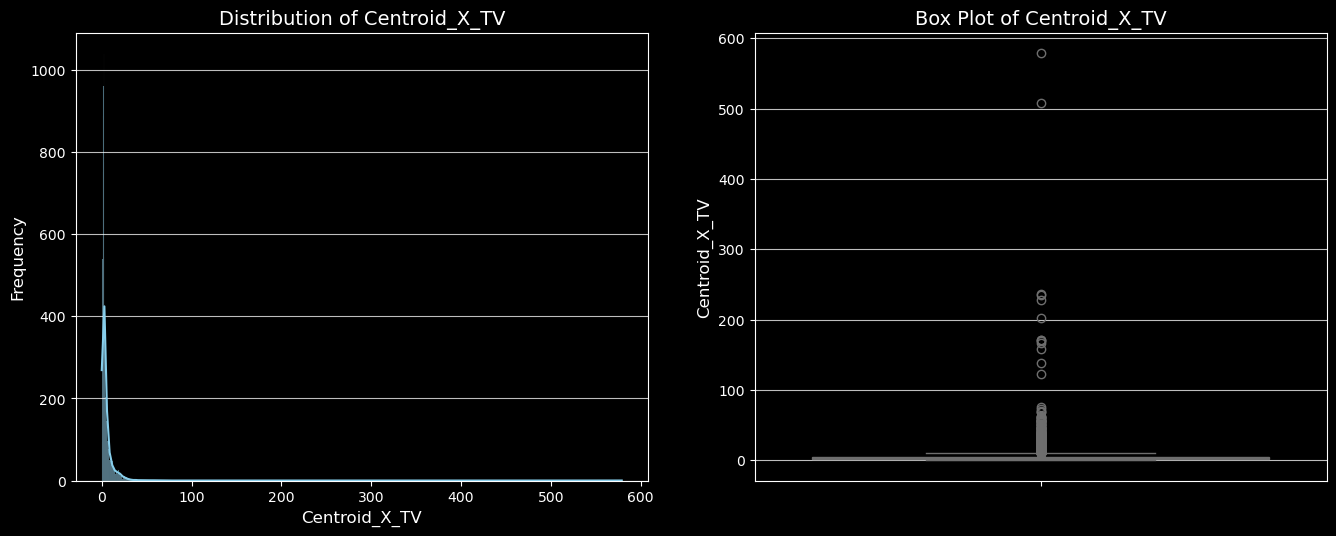


--- Scatter Plots for 'Centroid_X_TV' vs. Top Correlated Features ---


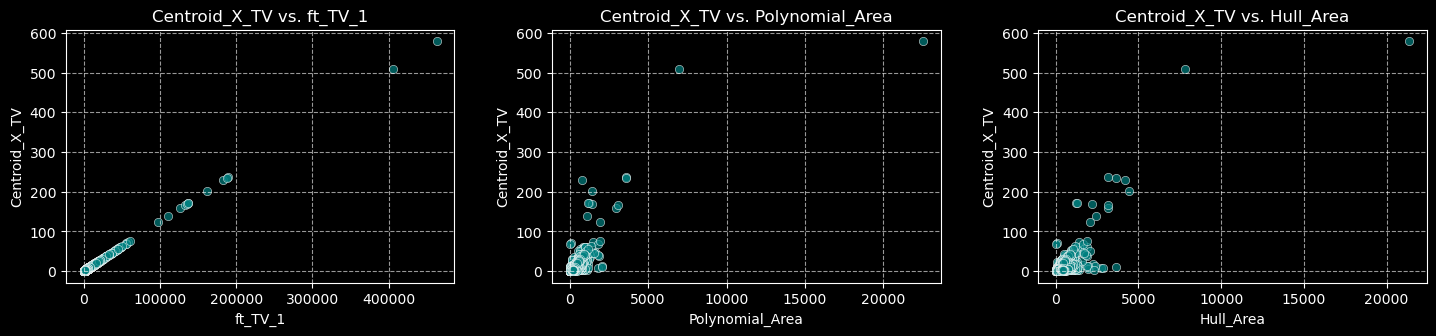


--- Exploring how 'Centroid_X_TV' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'Centroid_X_TV' by Bins of 'ft_TV_1' ---

Summary Statistics of 'Centroid_X_TV' by 'ft_TV_1' Bins:
                    count       mean        std       min       25%       50%  \
ft_TV_1_Binned_Q4                                                               
Q1                 2430.0   1.176282   0.350222  0.057796  0.991251  1.211370   
Q2                 2430.0   2.125831   0.255993  1.692548  1.886639  2.137369   
Q3                 2429.0   3.461348   0.749374  2.538274  2.823579  3.262460   
Q4                 2430.0  13.920948  21.078286  5.162267  6.889385  9.717960   

                         75%         max  
ft_TV_1_Binned_Q4                         
Q1                  1.457030    1.692505  
Q2                  2.367793    2.537409  
Q3                  4.020740    5.158440  
Q4                 16.172936  578.953455  


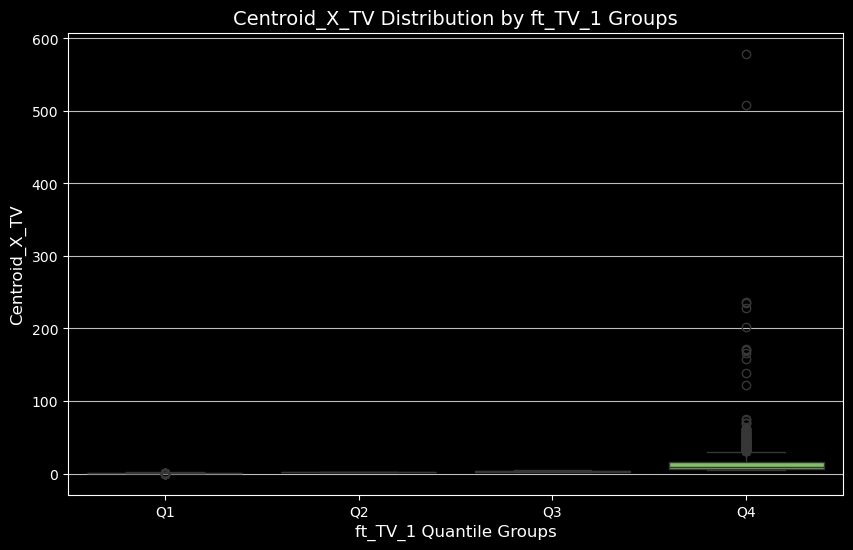

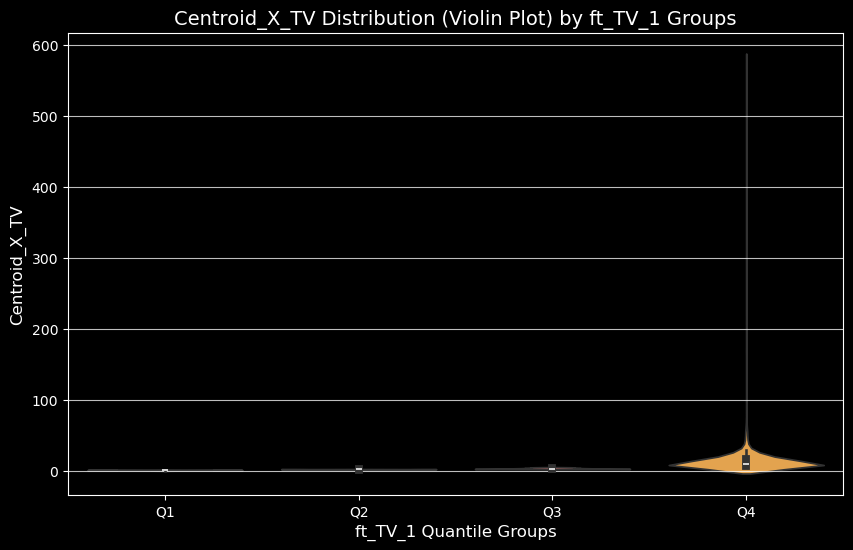


--- Grouped Analysis: 'Centroid_X_TV' by Bins of 'Polynomial_Area' ---

Summary Statistics of 'Centroid_X_TV' by 'Polynomial_Area' Bins:
                            count       mean        std       min       25%  \
Polynomial_Area_Binned_Q4                                                     
Q1                         2430.0   2.502957   3.020469  0.057796  1.116183   
Q2                         2430.0   2.822316   2.422993  0.058184  1.415326   
Q3                         2429.0   3.644560   3.240444  0.844334  1.882091   
Q4                         2430.0  11.714652  21.598695  0.633187  3.357624   

                                50%        75%         max  
Polynomial_Area_Binned_Q4                                   
Q1                         1.671487   2.812425   69.947734  
Q2                         2.252161   3.046624   28.083104  
Q3                         2.487260   3.775101   34.317228  
Q4                         7.091726  15.169819  578.953455  


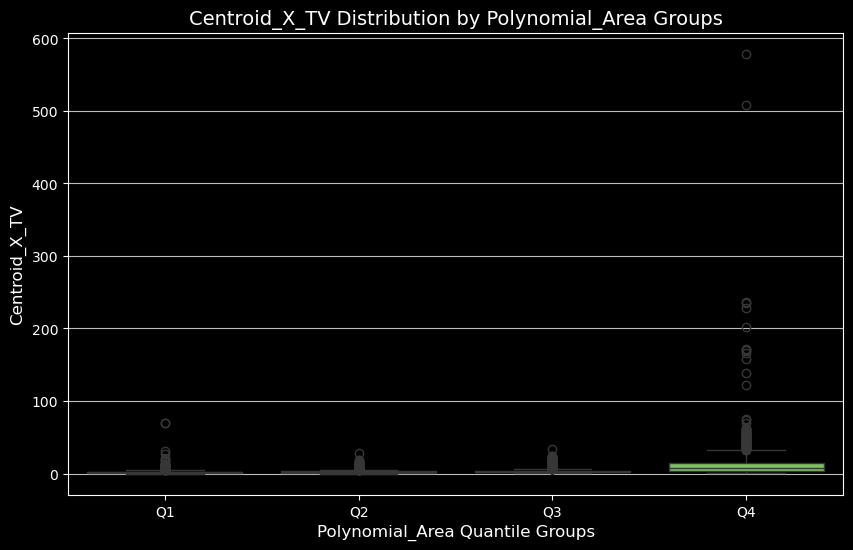

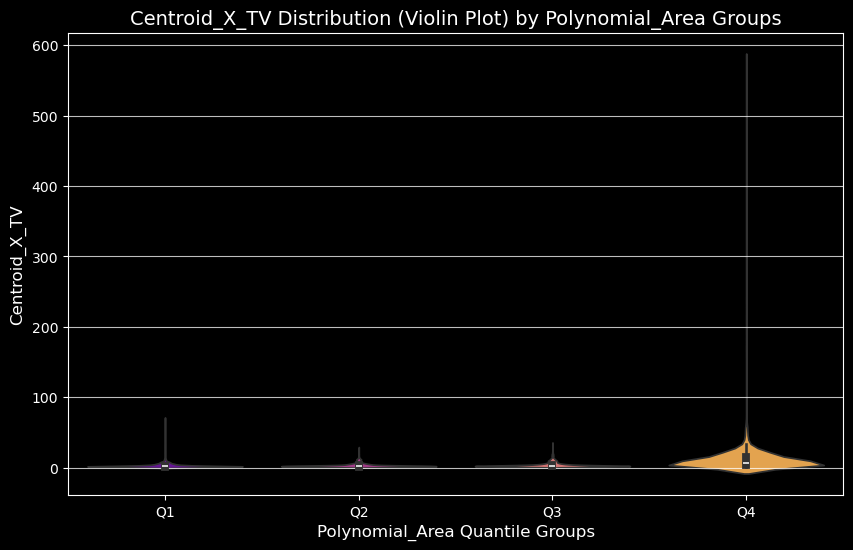


==================== END OF ANALYSIS FOR FEATURE: Centroid_X_TV ====================



==================== DETAILED ANALYSIS FOR FEATURE: Centroid_Y_P ====================

--- Analyzing Feature: 'Centroid_Y_P' ---

Summary Statistics for 'Centroid_Y_P':
count    9719.000000
mean        2.348669
std         0.943918
min        -0.425188
25%         1.771662
50%         2.387525
75%         2.876200
max        10.250500
Name: Centroid_Y_P, dtype: float64


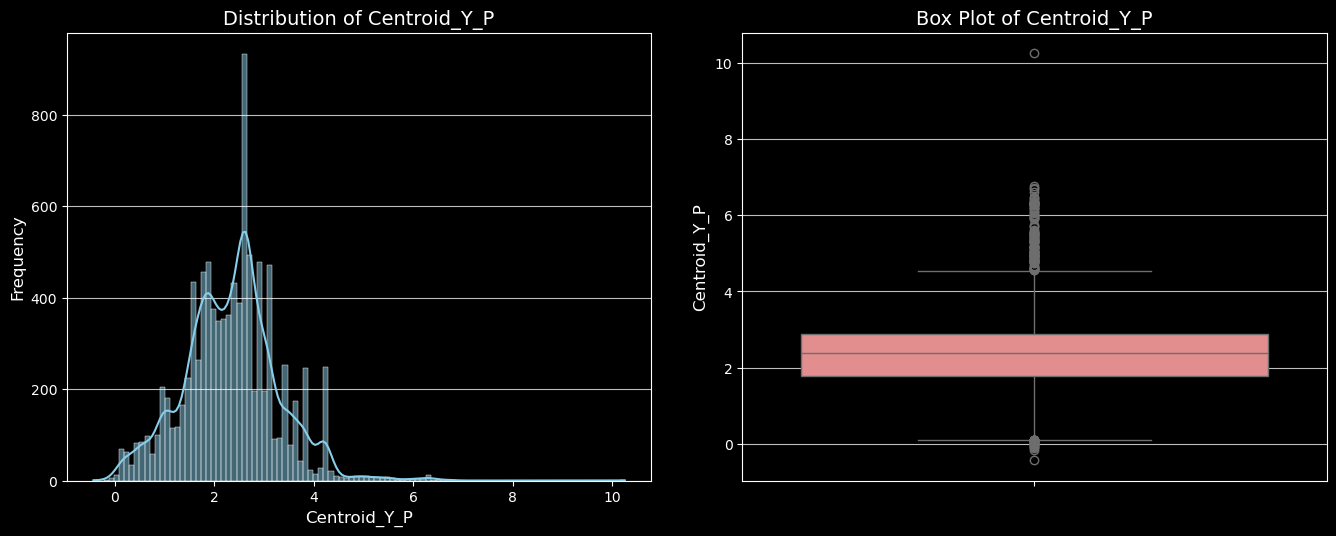


--- Scatter Plots for 'Centroid_Y_P' vs. Top Correlated Features ---


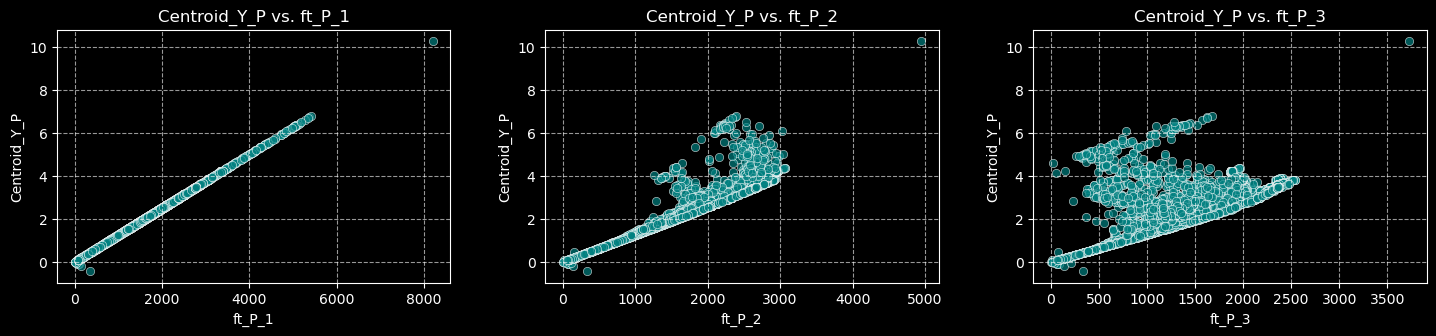


--- Exploring how 'Centroid_Y_P' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'Centroid_Y_P' by Bins of 'ft_P_1' ---

Summary Statistics of 'Centroid_Y_P' by 'ft_P_1' Bins:
                   count      mean       std       min       25%       50%  \
ft_P_1_Binned_Q4                                                             
Q1                2430.0  1.185471  0.463225 -0.425188  0.909553  1.313875   
Q2                2430.0  2.058807  0.186440  1.771675  1.878078  2.048694   
Q3                2429.0  2.624869  0.124471  2.387862  2.539588  2.618200   
Q4                2430.0  3.525642  0.632515  2.876500  3.082094  3.407831   

                       75%        max  
ft_P_1_Binned_Q4                       
Q1                1.584150   1.771650  
Q2                2.224731   2.387525  
Q3                2.707600   2.875900  
Q4                3.823234  10.250500  


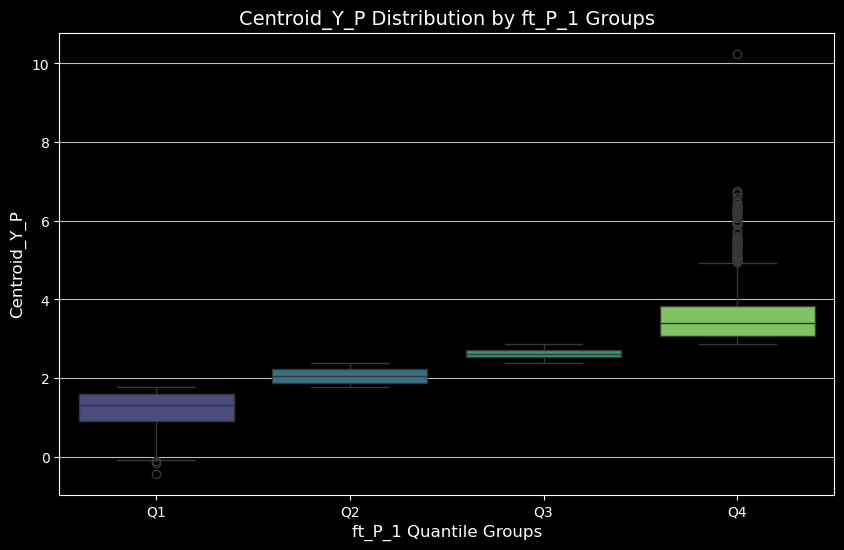

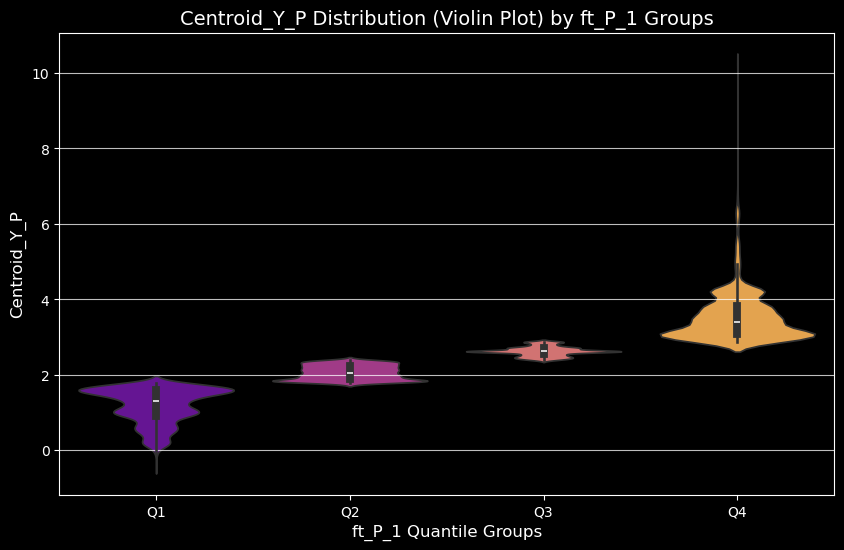


--- Grouped Analysis: 'Centroid_Y_P' by Bins of 'ft_P_2' ---

Summary Statistics of 'Centroid_Y_P' by 'ft_P_2' Bins:
                   count      mean       std       min       25%       50%  \
ft_P_2_Binned_Q4                                                             
Q1                2430.0  1.191159  0.478826 -0.425188  0.909553  1.313875   
Q2                2430.0  2.098302  0.314311  1.710037  1.876359  2.045925   
Q3                2429.0  2.616571  0.249231  2.246387  2.501425  2.614888   
Q4                2430.0  3.488752  0.631918  2.731200  3.063469  3.351469   

                       75%        max  
ft_P_2_Binned_Q4                       
Q1                1.584150   4.033025  
Q2                2.223750   4.570450  
Q3                2.701125   6.106975  
Q4                3.821337  10.250500  


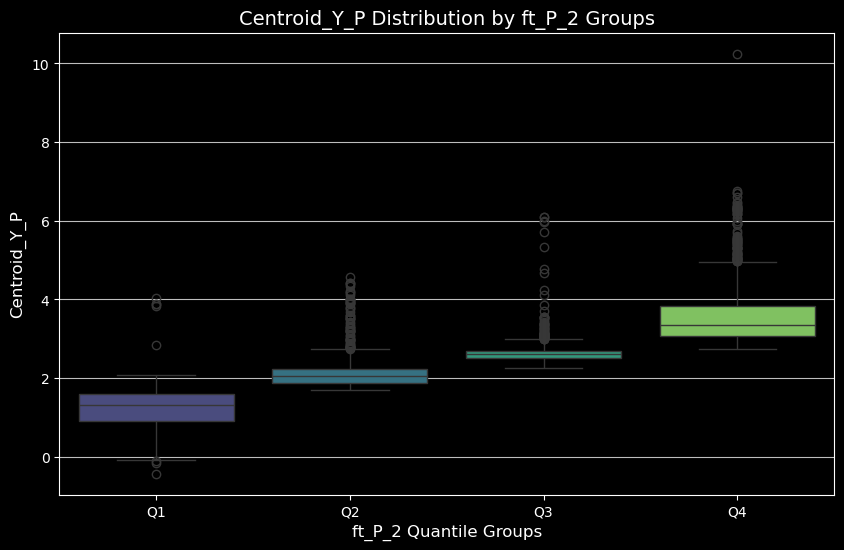

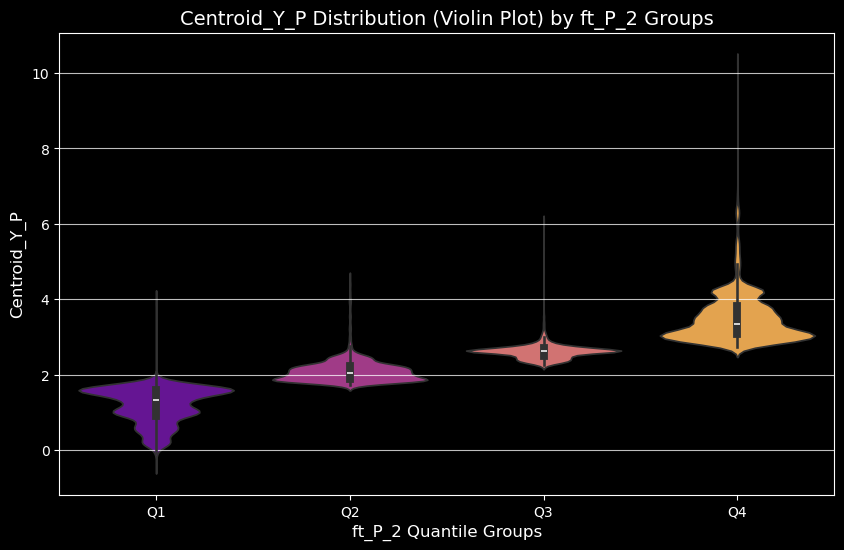


==================== END OF ANALYSIS FOR FEATURE: Centroid_Y_P ====================



==================== DETAILED ANALYSIS FOR FEATURE: Height_P_Range ====================

--- Analyzing Feature: 'Height_P_Range' ---

Summary Statistics for 'Height_P_Range':
count    9719.000000
mean       26.294748
std         7.105605
min         0.650000
25%        20.530000
50%        25.690000
75%        32.500000
max        70.630000
Name: Height_P_Range, dtype: float64


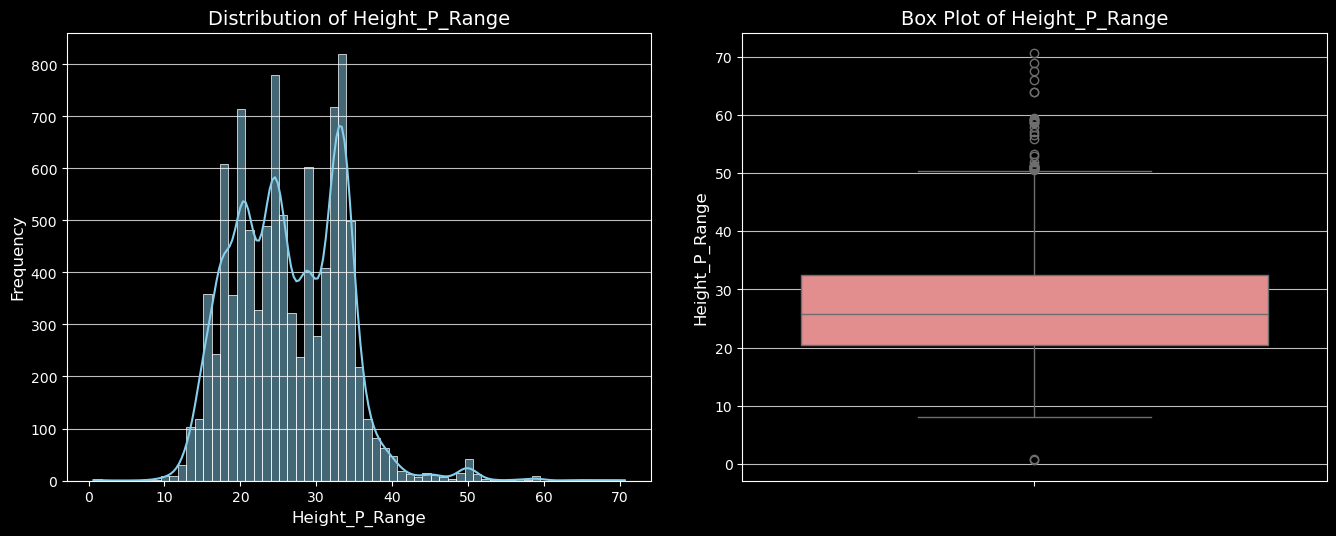


--- Scatter Plots for 'Height_P_Range' vs. Top Correlated Features ---


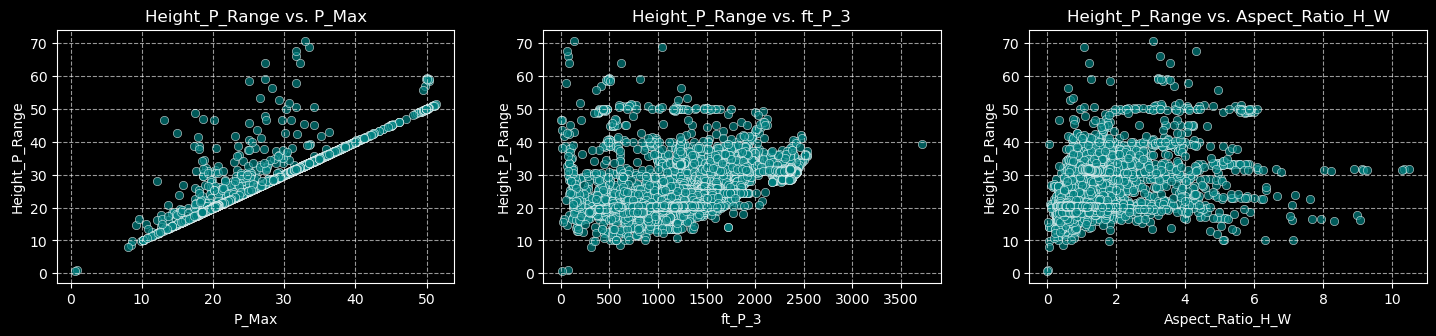


--- Exploring how 'Height_P_Range' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'Height_P_Range' by Bins of 'P_Max' ---

Summary Statistics of 'Height_P_Range' by 'P_Max' Bins:
                  count       mean       std    min    25%    50%    75%  \
P_Max_Binned_Q4                                                            
Q1               2439.0  17.822833  2.963811   0.65  15.97  17.64  19.50   
Q2               2421.0  23.265233  2.123060  20.48  21.64  23.46  24.43   
Q3               2431.0  29.110564  3.123522  25.54  26.99  28.76  30.88   
Q4               2428.0  35.006532  3.732006  32.46  33.04  33.87  35.23   

                   max  
P_Max_Binned_Q4         
Q1               48.86  
Q2               58.55  
Q3               67.61  
Q4               70.63  


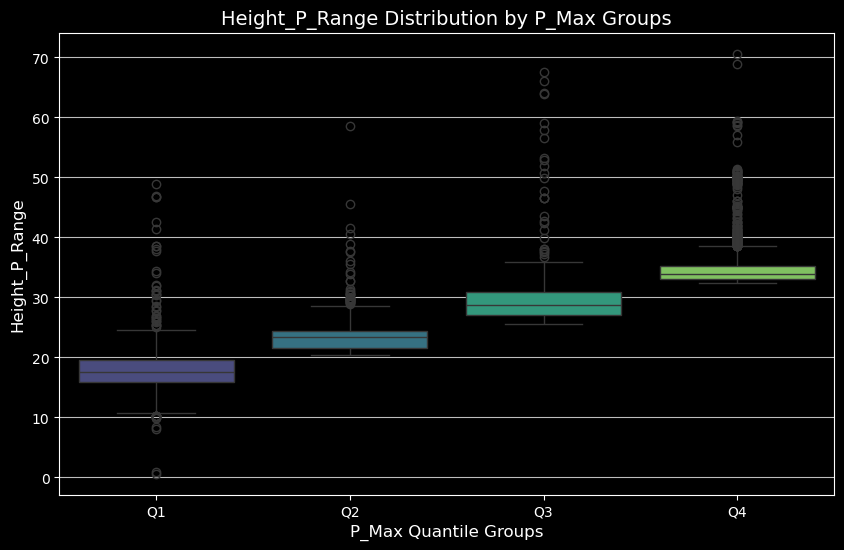

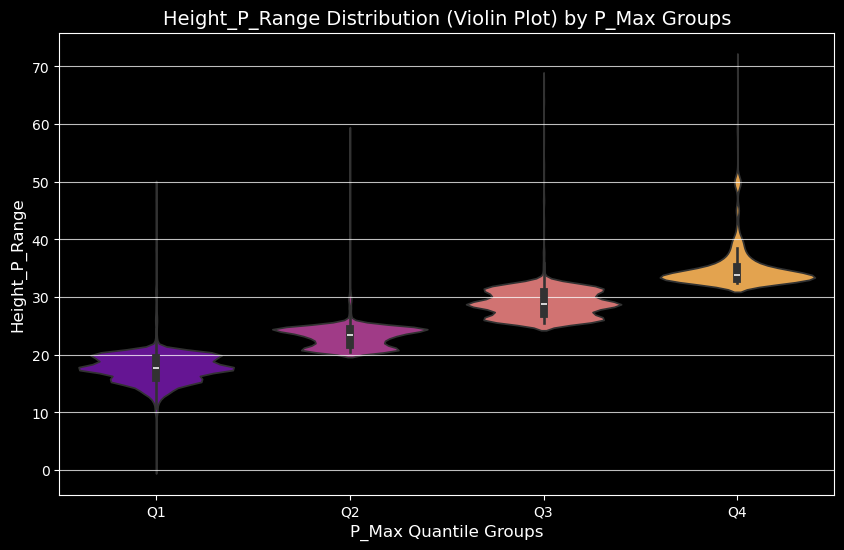


--- Grouped Analysis: 'Height_P_Range' by Bins of 'ft_P_3' ---

Summary Statistics of 'Height_P_Range' by 'ft_P_3' Bins:
                   count       mean       std    min      25%     50%  \
ft_P_3_Binned_Q4                                                        
Q1                2430.0  21.309243  7.977601   0.65  16.4300  19.435   
Q2                2430.0  22.973498  5.365556  10.79  19.9725  22.090   
Q3                2429.0  28.208094  4.749359  14.01  24.6900  27.610   
Q4                2430.0  32.688947  2.560738  17.99  31.7625  32.900   

                      75%    max  
ft_P_3_Binned_Q4                  
Q1                22.8575  70.63  
Q2                25.0150  56.49  
Q3                30.7800  50.23  
Q4                33.8900  49.48  


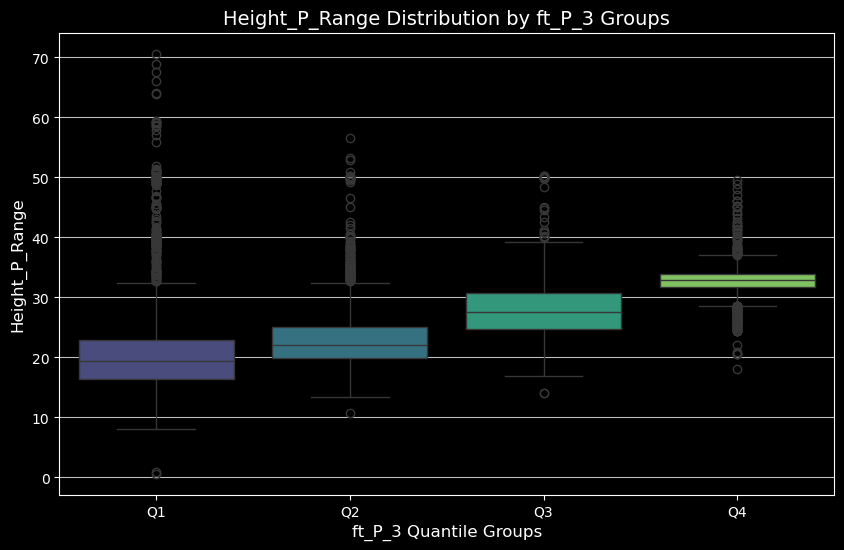

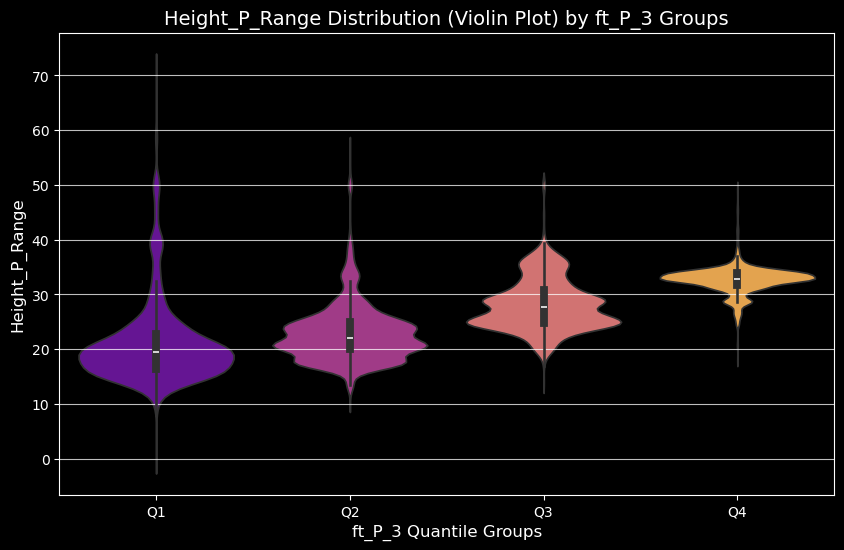


==================== END OF ANALYSIS FOR FEATURE: Height_P_Range ====================



==================== DETAILED ANALYSIS FOR FEATURE: Hull_Area ====================

--- Analyzing Feature: 'Hull_Area' ---

Summary Statistics for 'Hull_Area':
count     9719.000000
mean       389.133226
std        313.461129
min          6.371891
25%        259.181420
50%        365.623506
75%        466.684888
max      21359.120645
Name: Hull_Area, dtype: float64


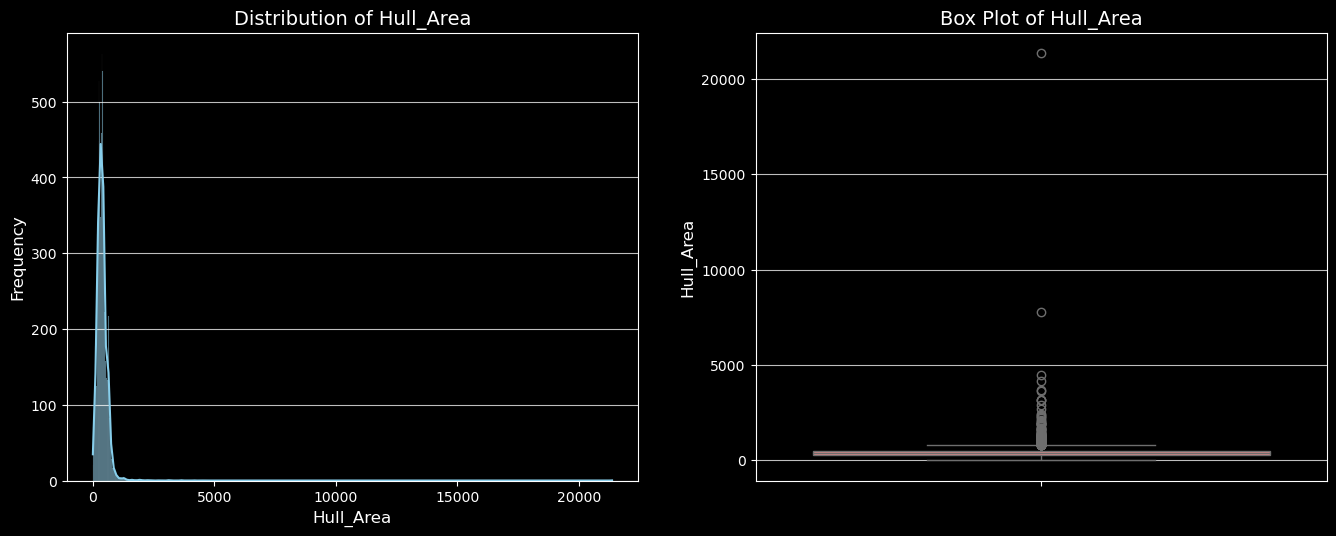


--- Scatter Plots for 'Hull_Area' vs. Top Correlated Features ---


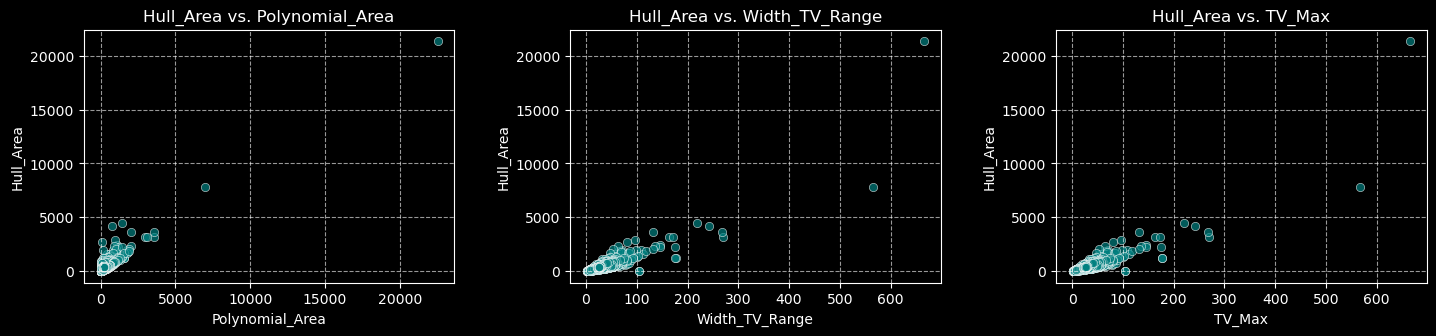


--- Exploring how 'Hull_Area' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'Hull_Area' by Bins of 'Polynomial_Area' ---

Summary Statistics of 'Hull_Area' by 'Polynomial_Area' Bins:
                            count        mean         std         min  \
Polynomial_Area_Binned_Q4                                               
Q1                         2430.0  221.422268  135.414687    6.371891   
Q2                         2430.0  319.370574  105.169007  101.407892   
Q3                         2429.0  403.223016   93.263106  136.223157   
Q4                         2430.0  612.522844  521.431658  205.872596   

                                  25%         50%         75%           max  
Polynomial_Area_Binned_Q4                                                    
Q1                         127.761292  213.240548  274.804533   2713.360102  
Q2                         253.960103  298.224942  371.855854   1948.943992  
Q3                         354.92

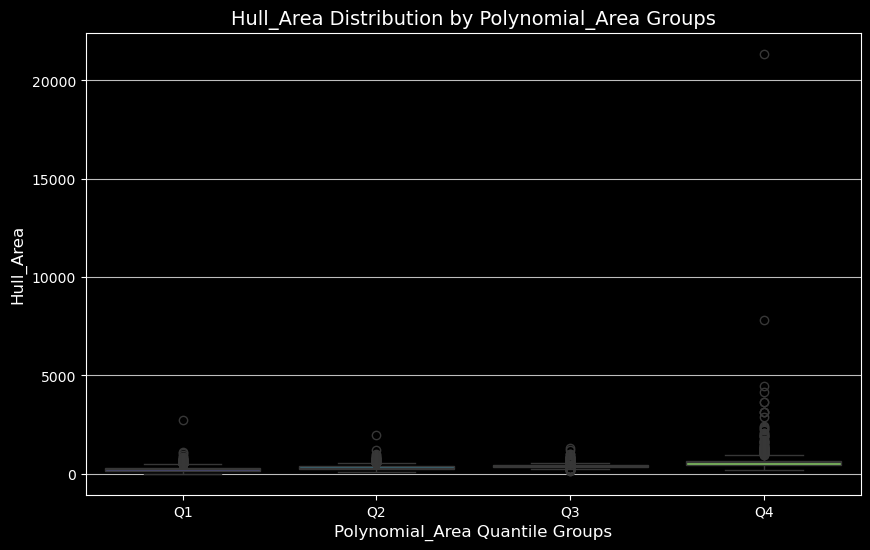

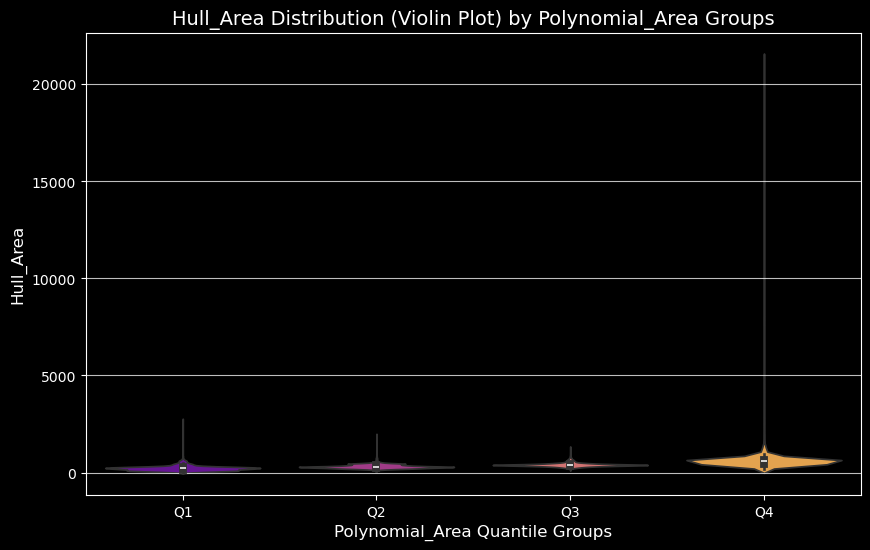


--- Grouped Analysis: 'Hull_Area' by Bins of 'TV_Max' ---

Summary Statistics of 'Hull_Area' by 'TV_Max' Bins:
                   count        mean         std         min         25%  \
TV_Max_Binned_Q4                                                           
Q1                2430.0  199.647589   86.929991    6.371891  129.451314   
Q2                2430.0  357.527661   96.136983   80.357715  277.290084   
Q3                2429.0  392.937062  111.490155  171.818893  306.452724   
Q4                2430.0  606.422157  528.886608   37.141096  437.634388   

                         50%         75%           max  
TV_Max_Binned_Q4                                        
Q1                206.078877  265.065500    504.085372  
Q2                374.720875  421.443994    693.150429  
Q3                376.685761  454.005792   1123.667638  
Q4                570.981868  670.929002  21359.120645  


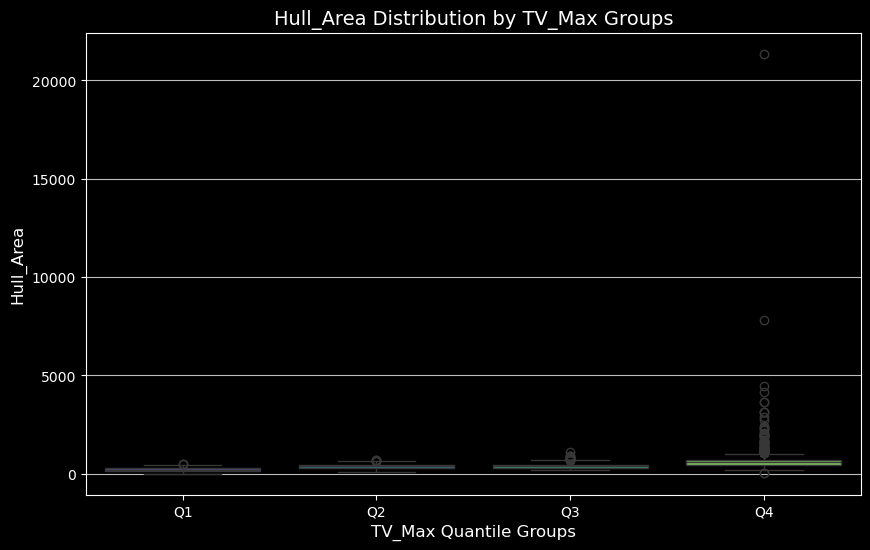

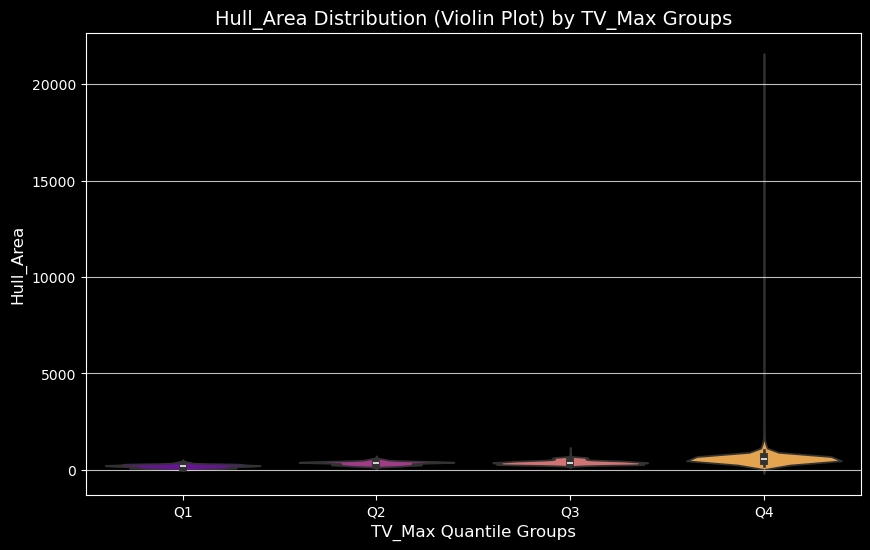


==================== END OF ANALYSIS FOR FEATURE: Hull_Area ====================



==================== DETAILED ANALYSIS FOR FEATURE: P_Max ====================

--- Analyzing Feature: 'P_Max' ---

Summary Statistics for 'P_Max':
count    9719.000000
mean       26.079053
std         6.913939
min         0.650000
25%        20.470000
50%        25.530000
75%        32.450000
max        51.380000
Name: P_Max, dtype: float64


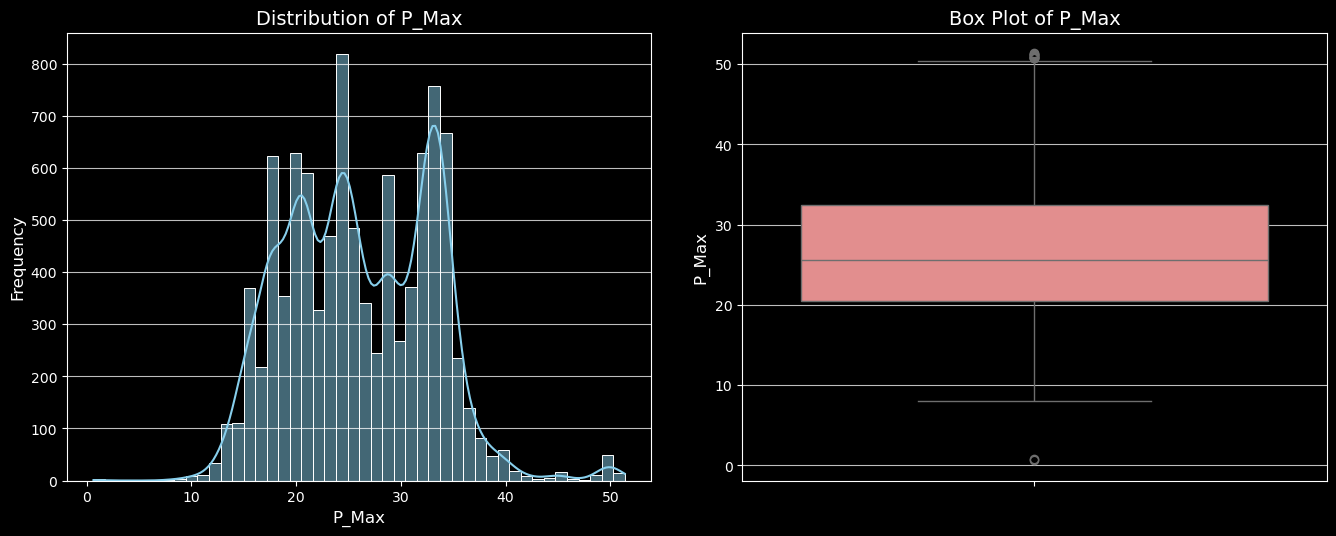


--- Scatter Plots for 'P_Max' vs. Top Correlated Features ---


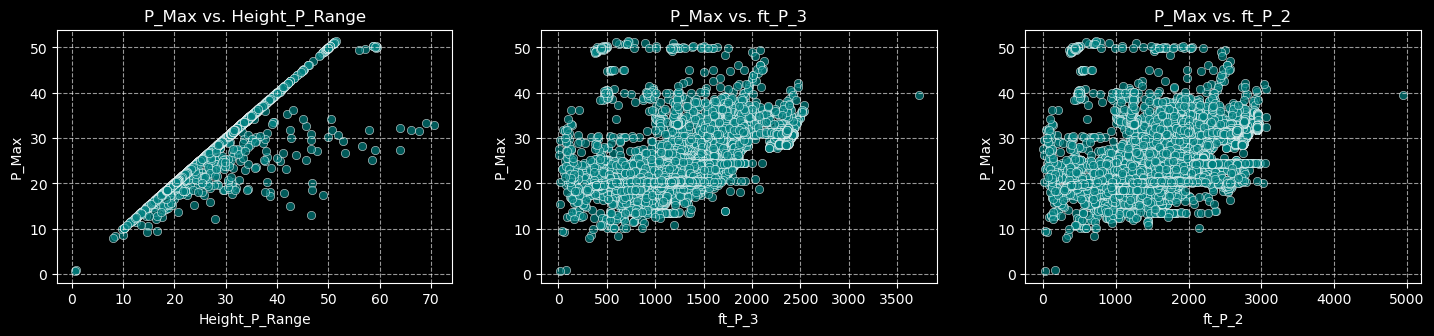


--- Exploring how 'P_Max' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'P_Max' by Bins of 'Height_P_Range' ---

Summary Statistics of 'P_Max' by 'Height_P_Range' Bins:
                           count       mean       std    min     25%    50%  \
Height_P_Range_Binned_Q4                                                      
Q1                        2443.0  17.585460  2.217788   0.65  15.735  17.64   
Q2                        2424.0  23.167838  1.632171  13.70  21.700  23.52   
Q3                        2429.0  28.882532  2.384506  12.20  27.130  28.79   
Q4                        2423.0  34.744750  3.771177  13.09  33.050  33.87   

                             75%    max  
Height_P_Range_Binned_Q4                 
Q1                        19.480  20.53  
Q2                        24.450  25.69  
Q3                        30.970  32.50  
Q4                        35.175  51.38  


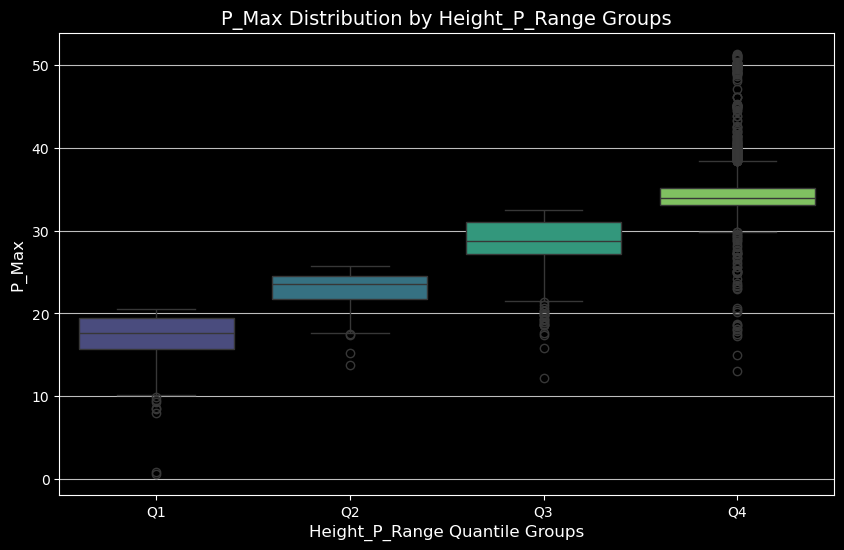

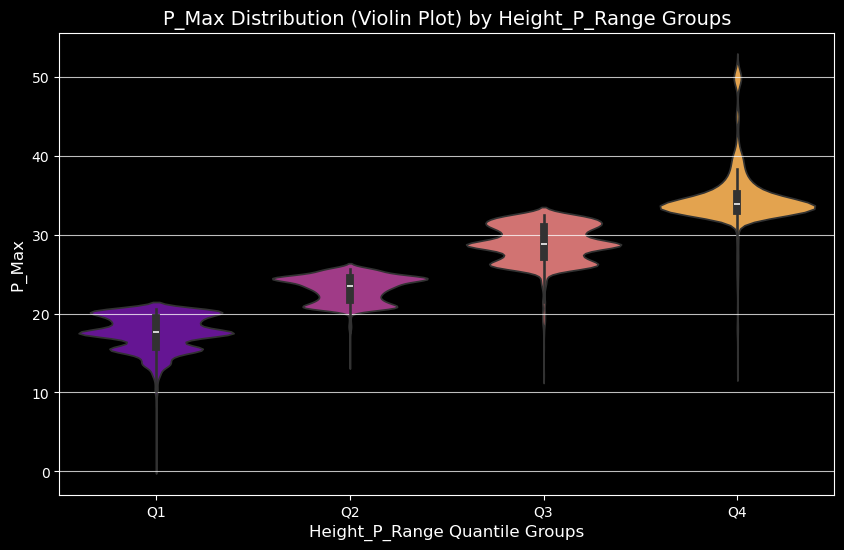


--- Grouped Analysis: 'P_Max' by Bins of 'ft_P_3' ---

Summary Statistics of 'P_Max' by 'ft_P_3' Bins:
                   count       mean       std    min      25%    50%      75%  \
ft_P_3_Binned_Q4                                                                
Q1                2430.0  20.529128  6.790567   0.65  16.1125  19.18  22.0275   
Q2                2430.0  22.902918  5.201083  10.79  19.9625  22.08  24.9500   
Q3                2429.0  28.200226  4.740948  13.87  24.6900  27.61  30.7800   
Q4                2430.0  32.684815  2.561134  17.99  31.7625  32.90  33.8900   

                    max  
ft_P_3_Binned_Q4         
Q1                51.38  
Q2                50.92  
Q3                50.23  
Q4                49.48  


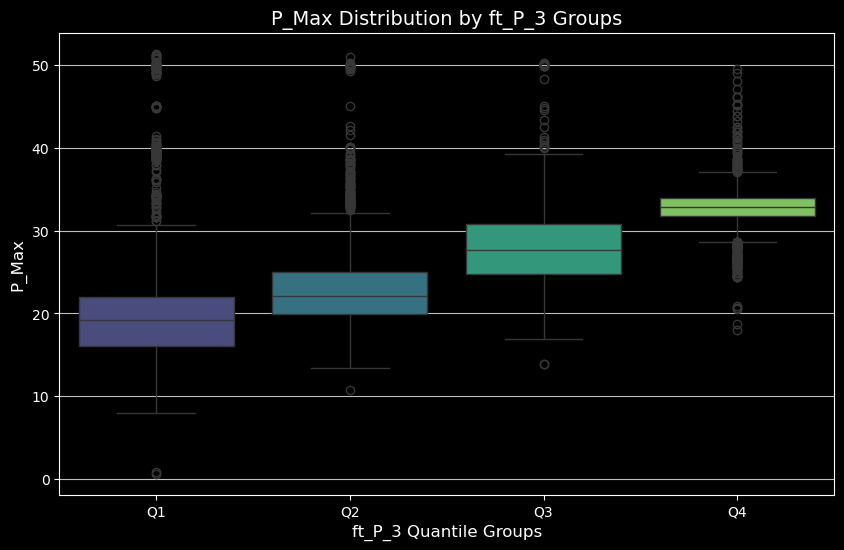

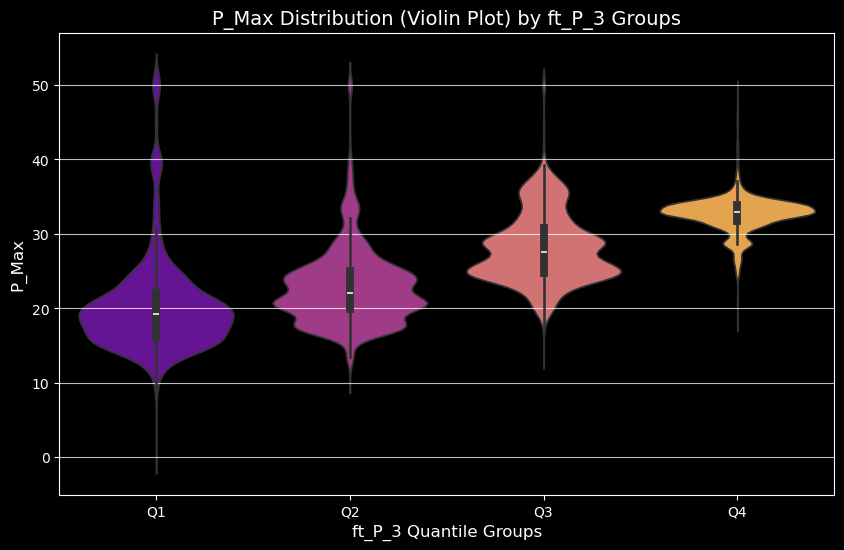


==================== END OF ANALYSIS FOR FEATURE: P_Max ====================



==================== DETAILED ANALYSIS FOR FEATURE: Perimeter ====================

--- Analyzing Feature: 'Perimeter' ---

Summary Statistics for 'Perimeter':
count    9719.000000
mean       86.660660
std        26.173196
min        18.585758
25%        71.585903
50%        84.772206
75%        95.782909
max       790.381927
Name: Perimeter, dtype: float64


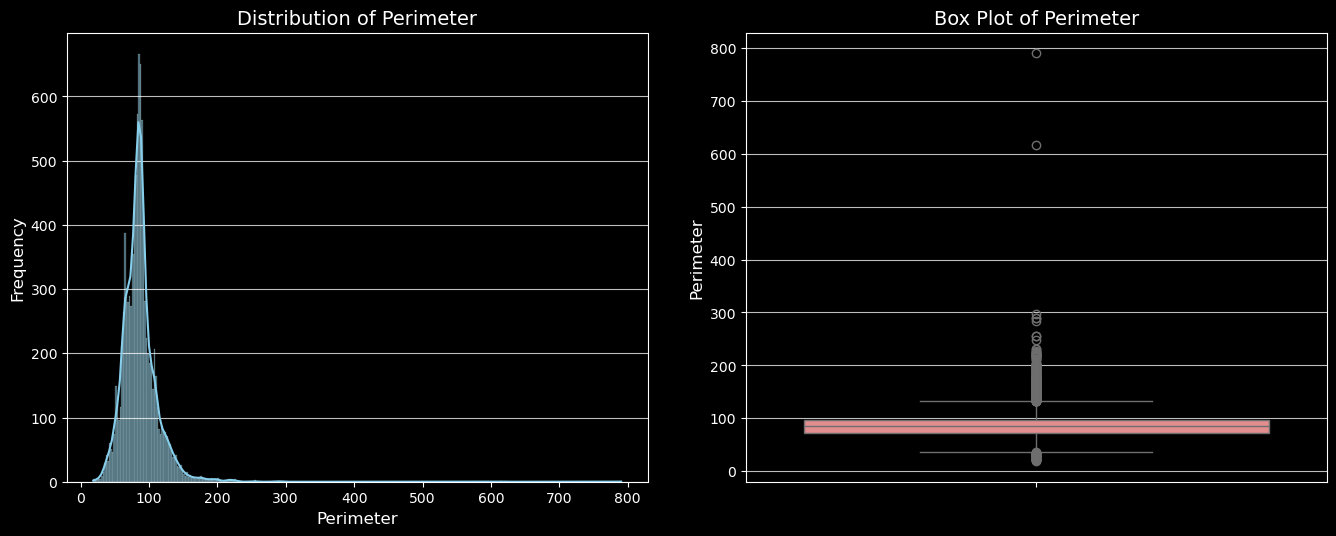


--- Scatter Plots for 'Perimeter' vs. Top Correlated Features ---


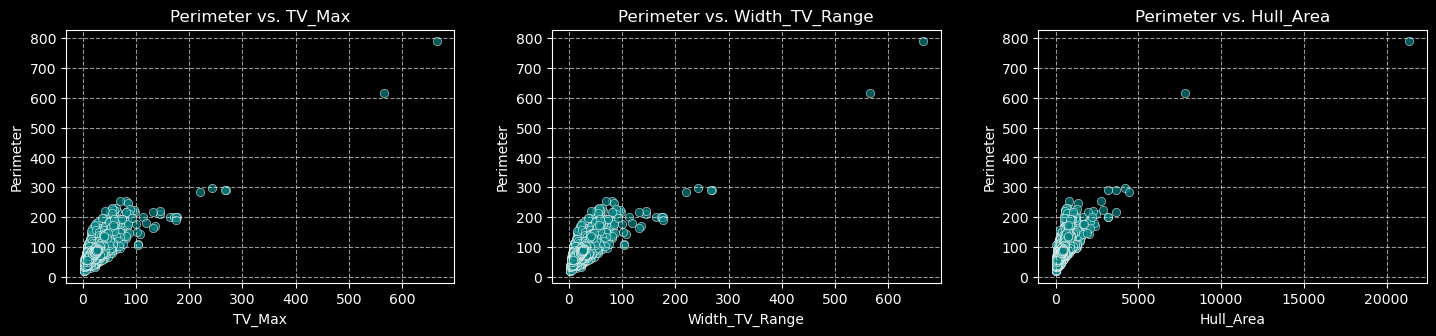


--- Exploring how 'Perimeter' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'Perimeter' by Bins of 'TV_Max' ---

Summary Statistics of 'Perimeter' by 'TV_Max' Bins:
                   count        mean        std        min        25%  \
TV_Max_Binned_Q4                                                        
Q1                2430.0   69.446607  19.233410  18.585758  56.243527   
Q2                2430.0   81.225869  17.785082  33.600807  69.126906   
Q3                2429.0   86.097007  13.016004  49.349476  78.184860   
Q4                2430.0  109.872923  31.934082  55.895459  91.558720   

                         50%         75%         max  
TV_Max_Binned_Q4                                      
Q1                 66.605784   81.867813  159.371896  
Q2                 82.661794   87.328815  179.853835  
Q3                 84.368550   91.381039  182.194947  
Q4                104.245858  119.614408  790.381927  


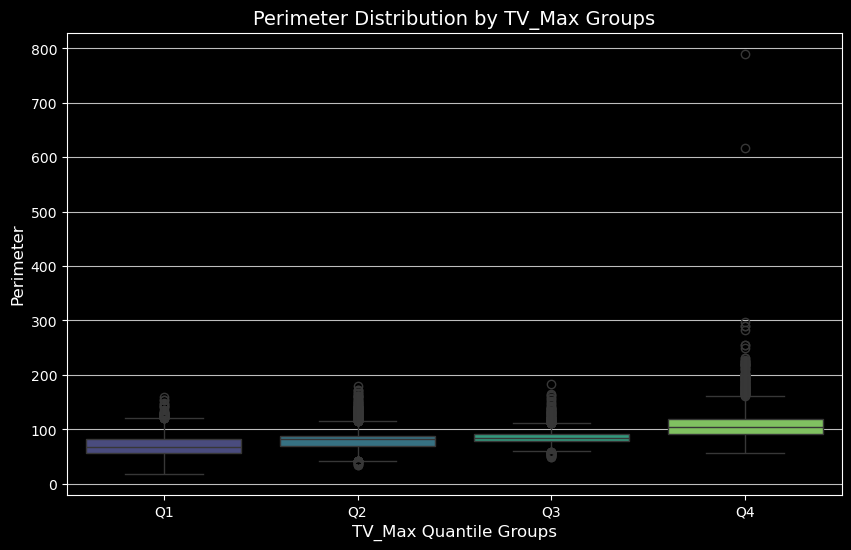

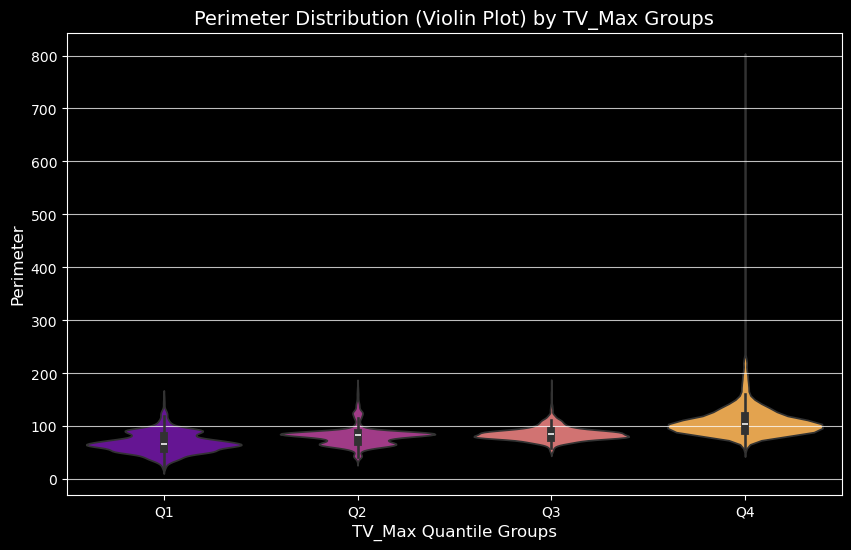


--- Grouped Analysis: 'Perimeter' by Bins of 'Width_TV_Range' ---

Summary Statistics of 'Perimeter' by 'Width_TV_Range' Bins:
                           count        mean        std        min        25%  \
Width_TV_Range_Binned_Q4                                                        
Q1                        2430.0   69.446607  19.233410  18.585758  56.243527   
Q2                        2430.0   81.225869  17.785082  33.600807  69.126906   
Q3                        2429.0   86.097007  13.016004  49.349476  78.184860   
Q4                        2430.0  109.872923  31.934082  55.895459  91.558720   

                                 50%         75%         max  
Width_TV_Range_Binned_Q4                                      
Q1                         66.605784   81.867813  159.371896  
Q2                         82.661794   87.328815  179.853835  
Q3                         84.368550   91.381039  182.194947  
Q4                        104.245858  119.614408  790.381927  


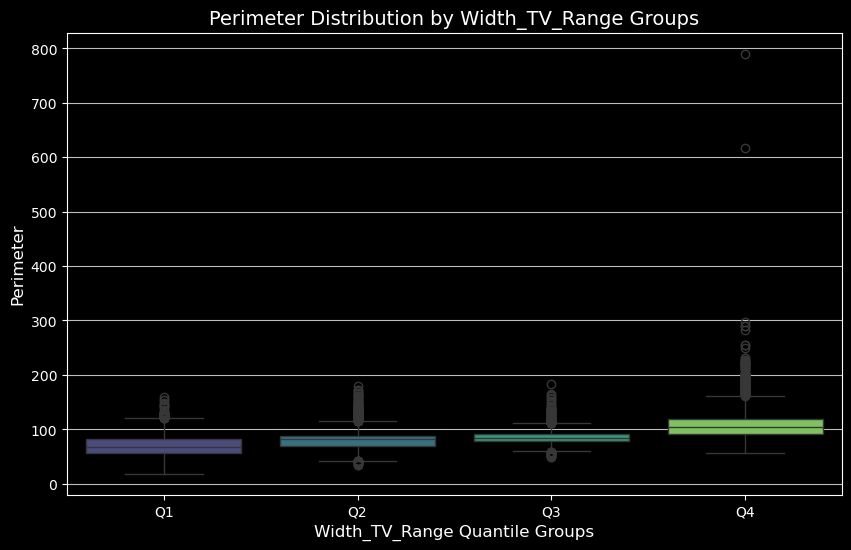

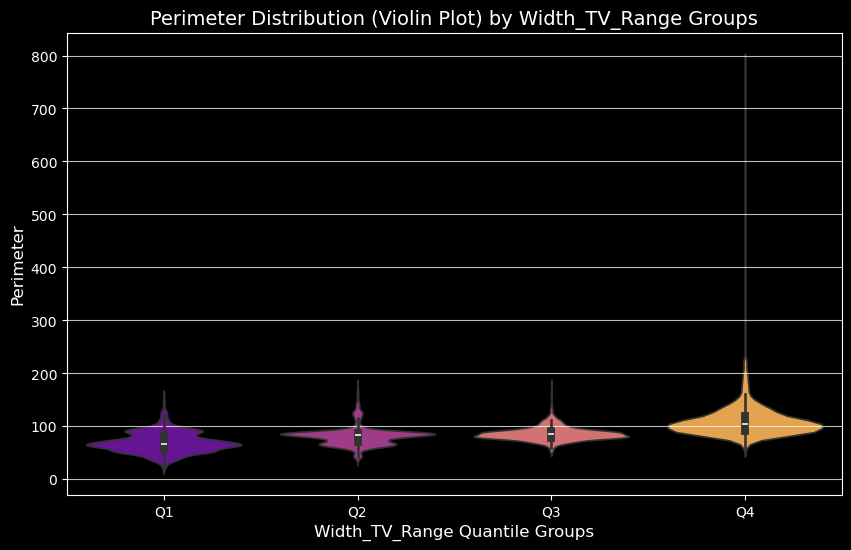


==================== END OF ANALYSIS FOR FEATURE: Perimeter ====================



==================== DETAILED ANALYSIS FOR FEATURE: Polynomial_Area ====================

--- Analyzing Feature: 'Polynomial_Area' ---

Summary Statistics for 'Polynomial_Area':
count     9719.000000
mean       254.712926
std        299.916061
min          0.123844
25%        136.059713
50%        214.993583
75%        330.344715
max      22530.401882
Name: Polynomial_Area, dtype: float64


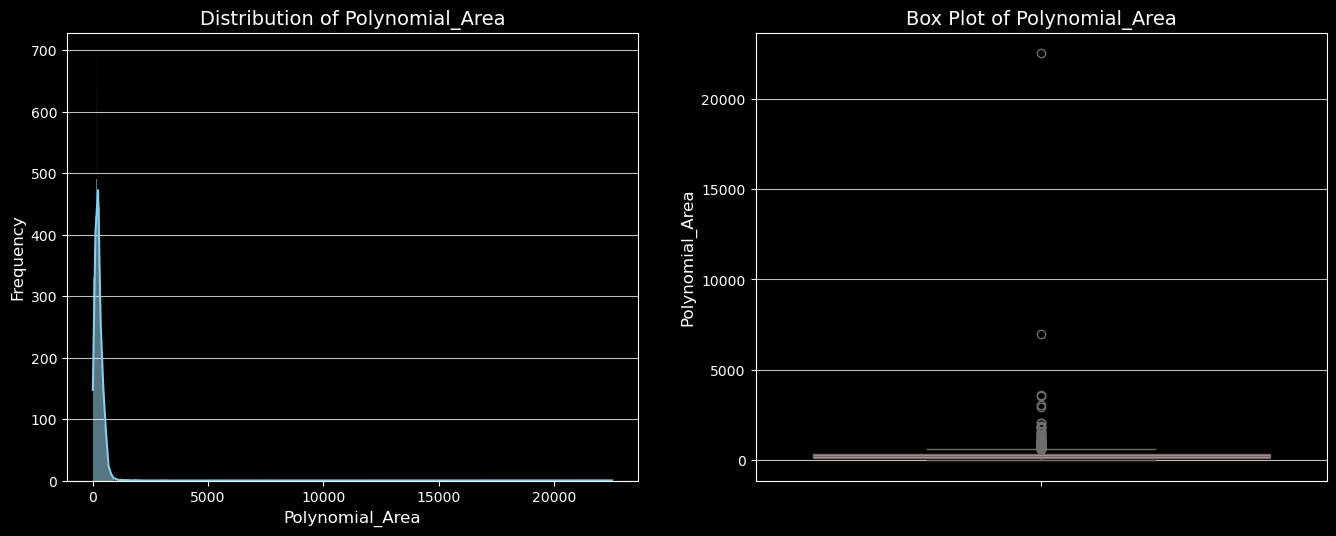


--- Scatter Plots for 'Polynomial_Area' vs. Top Correlated Features ---


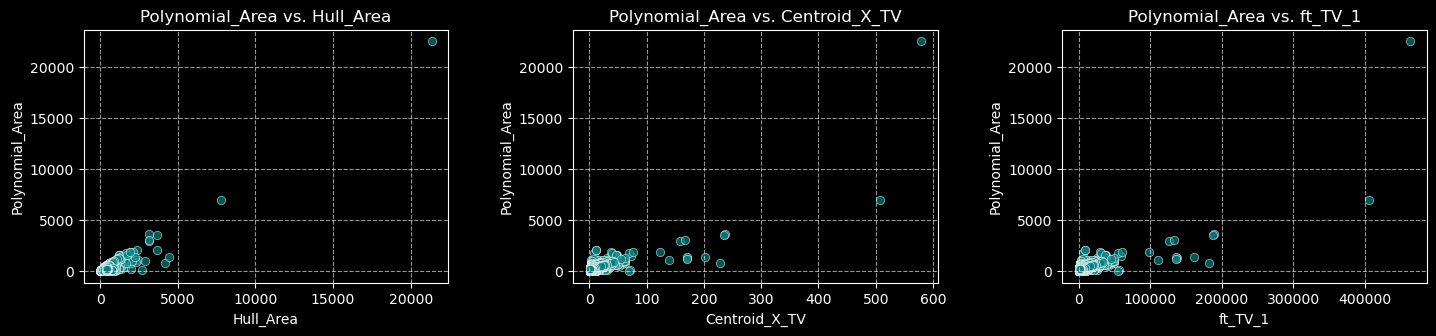


--- Exploring how 'Polynomial_Area' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'Polynomial_Area' by Bins of 'Hull_Area' ---

Summary Statistics of 'Polynomial_Area' by 'Hull_Area' Bins:
                      count        mean         std       min         25%  \
Hull_Area_Binned_Q4                                                         
Q1                   2430.0  104.390130   65.925249  0.142866   49.294180   
Q2                   2430.0  189.299599   77.815772  1.425620  152.721920   
Q3                   2429.0  273.503533   93.141414  0.123844  215.061915   
Q4                   2430.0  451.666174  524.168773  1.203827  320.737749   

                            50%         75%           max  
Hull_Area_Binned_Q4                                        
Q1                   107.024518  145.238764    392.128092  
Q2                   187.583533  233.276202    475.461768  
Q3                   271.042498  319.718616    608.712586  
Q4             

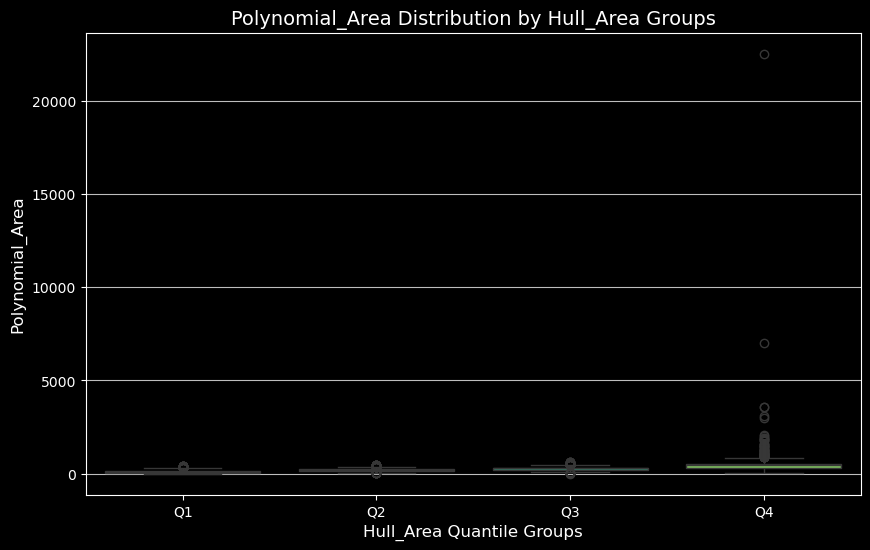

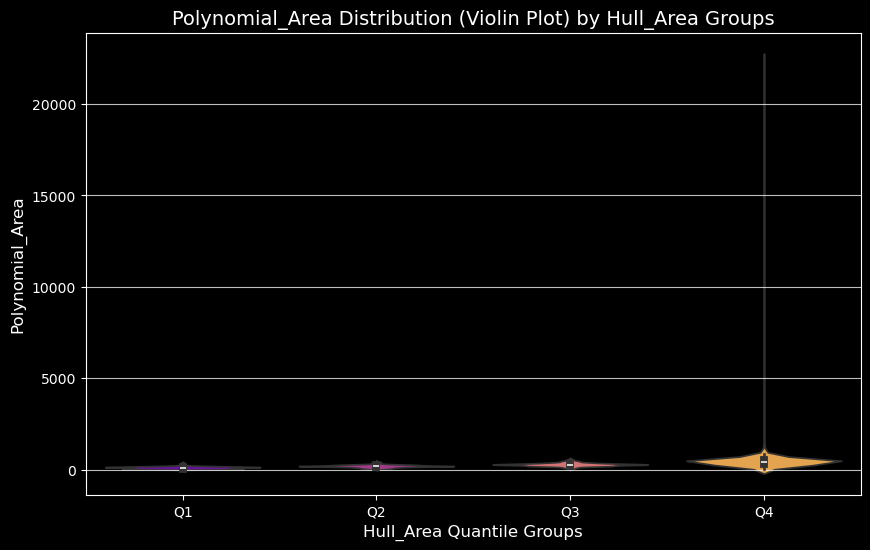


--- Grouped Analysis: 'Polynomial_Area' by Bins of 'Centroid_X_TV' ---

Summary Statistics of 'Polynomial_Area' by 'Centroid_X_TV' Bins:
                          count        mean         std       min         25%  \
Centroid_X_TV_Binned_Q4                                                         
Q1                       2430.0  134.871249   76.156715  0.142866   76.883299   
Q2                       2430.0  214.417273  102.009215  0.462586  154.735096   
Q3                       2429.0  256.740839  139.088970  0.123844  166.101896   
Q4                       2430.0  412.823178  532.281439  0.981780  241.048365   

                                50%         75%           max  
Centroid_X_TV_Binned_Q4                                        
Q1                       134.696048  182.587198    443.887896  
Q2                       209.438982  272.318327    662.327013  
Q3                       245.303158  337.552035   1067.034548  
Q4                       390.896146  525.799428  22530.

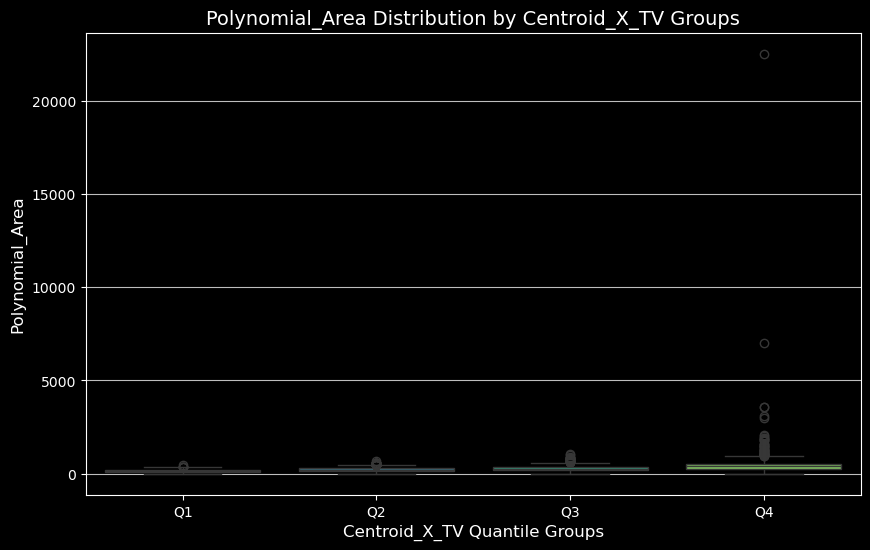

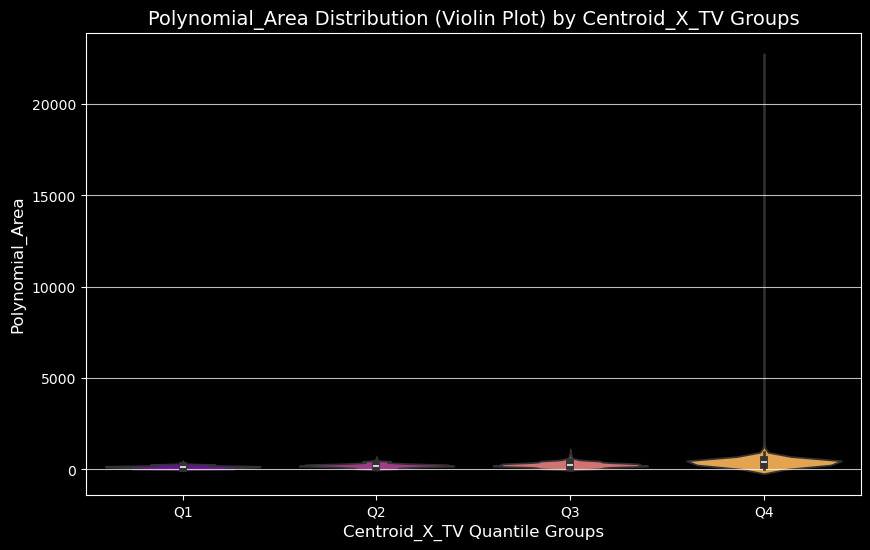


==================== END OF ANALYSIS FOR FEATURE: Polynomial_Area ====================



==================== DETAILED ANALYSIS FOR FEATURE: TV_Max ====================

--- Analyzing Feature: 'TV_Max' ---

Summary Statistics for 'TV_Max':
count    9719.000000
mean       27.423492
std        15.427924
min         1.433600
25%        19.812800
50%        25.652600
75%        32.358300
max       665.372600
Name: TV_Max, dtype: float64


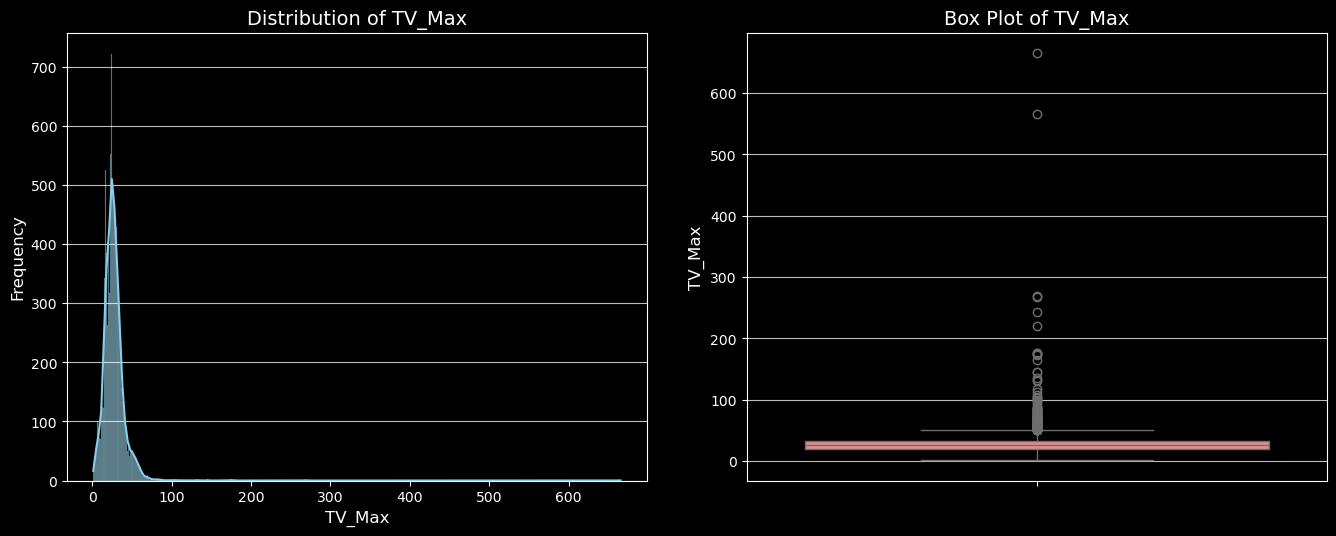


--- Scatter Plots for 'TV_Max' vs. Top Correlated Features ---


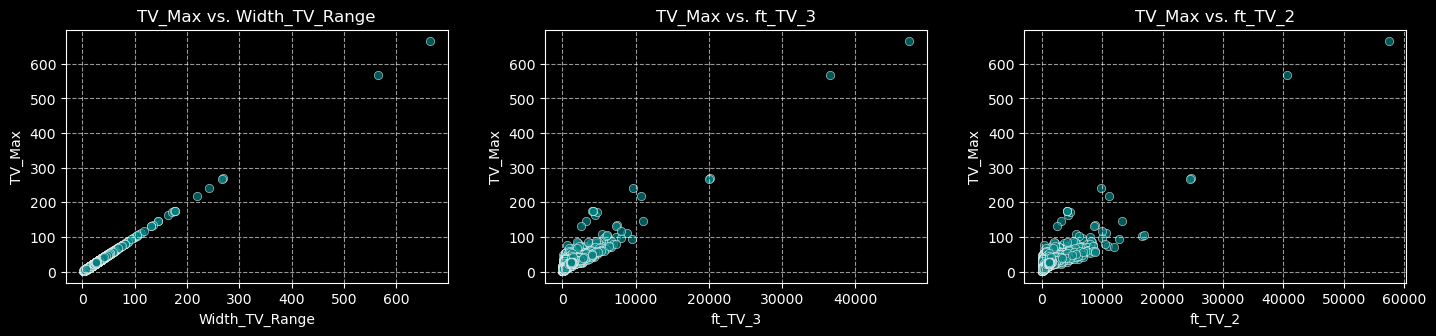


--- Exploring how 'TV_Max' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'TV_Max' by Bins of 'Width_TV_Range' ---

Summary Statistics of 'TV_Max' by 'Width_TV_Range' Bins:
                           count       mean        std      min       25%  \
Width_TV_Range_Binned_Q4                                                    
Q1                        2430.0  14.646727   4.282785   1.4336  12.34795   
Q2                        2430.0  23.159662   1.629011  19.8128  21.83005   
Q3                        2429.0  28.815059   1.873208  25.6568  27.20540   
Q4                        2430.0  43.073092  22.345650  32.3586  34.66130   

                              50%       75%       max  
Width_TV_Range_Binned_Q4                               
Q1                        16.4347  17.78285   19.8128  
Q2                        23.4440  24.52415   25.6526  
Q3                        28.7520  30.32500   32.3580  
Q4                        38.2564  46.33915  665.372

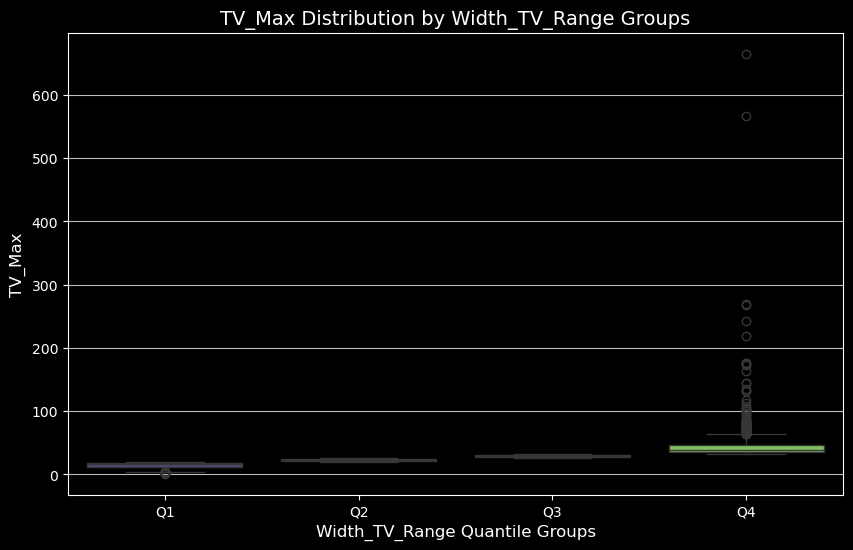

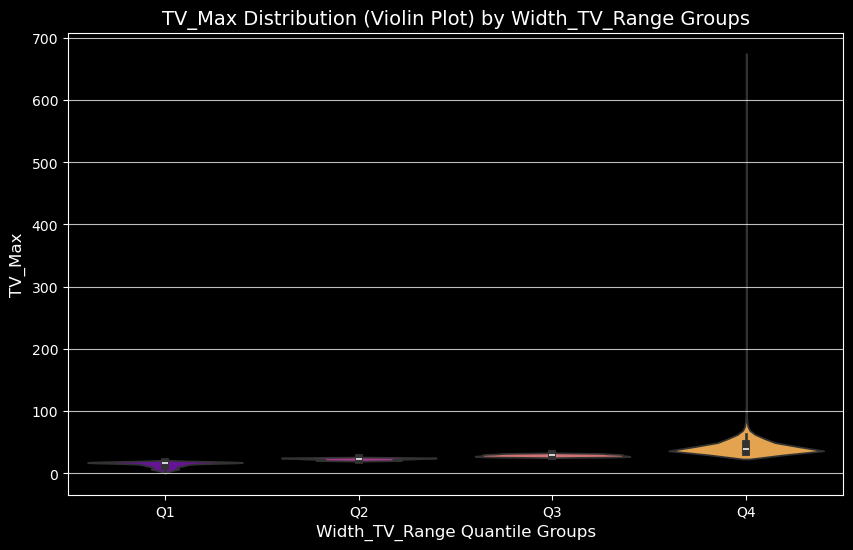


--- Grouped Analysis: 'TV_Max' by Bins of 'ft_TV_3' ---

Summary Statistics of 'TV_Max' by 'ft_TV_3' Bins:
                    count       mean        std      min       25%      50%  \
ft_TV_3_Binned_Q4                                                             
Q1                 2430.0  17.351560   8.023315   1.4336  12.34795  16.7015   
Q2                 2430.0  22.718302   5.393986  12.6602  18.79535  22.5679   
Q3                 2429.0  28.970940   5.156323  17.3804  25.95620  28.4724   
Q4                 2430.0  40.653802  23.045449  22.8382  32.42725  36.3317   

                        75%       max  
ft_TV_3_Binned_Q4                      
Q1                 21.33675   76.3576  
Q2                 24.76965   68.5200  
Q3                 30.67500   68.7586  
Q4                 44.61185  665.3726  


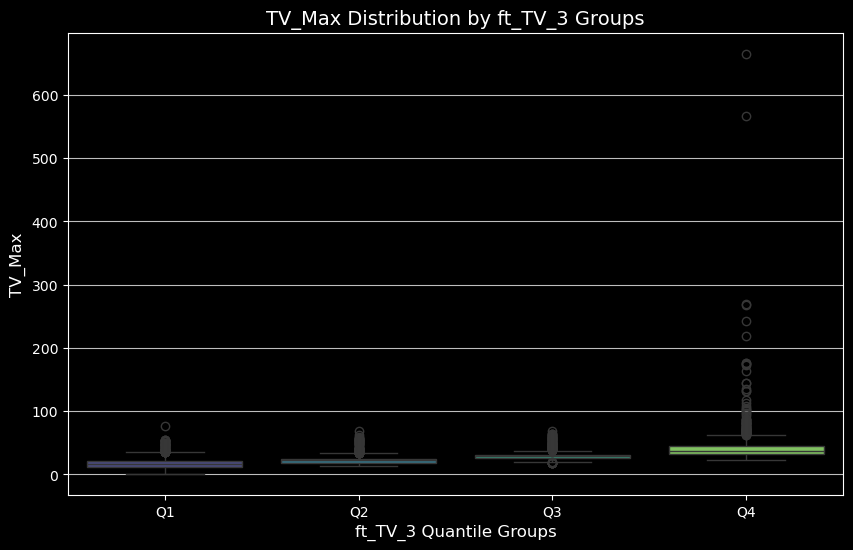

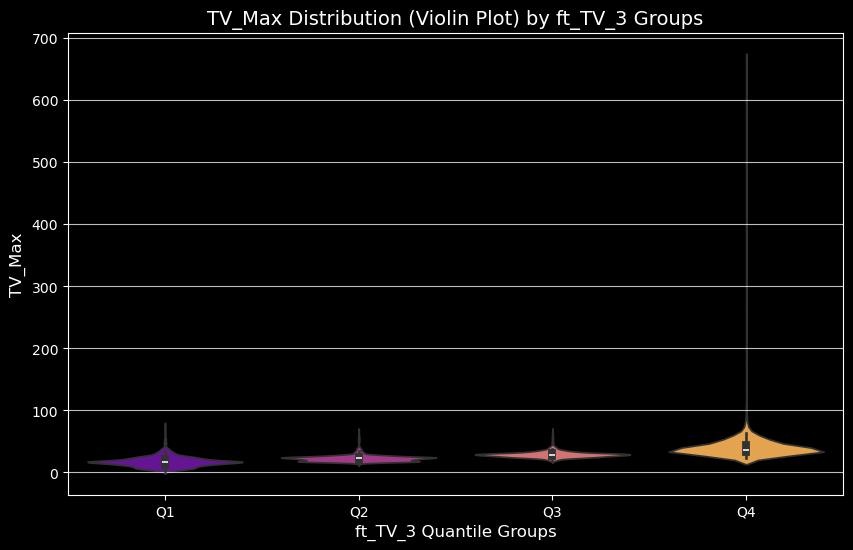


==================== END OF ANALYSIS FOR FEATURE: TV_Max ====================



==================== DETAILED ANALYSIS FOR FEATURE: Width_TV_Range ====================

--- Analyzing Feature: 'Width_TV_Range' ---

Summary Statistics for 'Width_TV_Range':
count    9719.000000
mean       27.423492
std        15.427924
min         1.433600
25%        19.812800
50%        25.652600
75%        32.358300
max       665.372600
Name: Width_TV_Range, dtype: float64


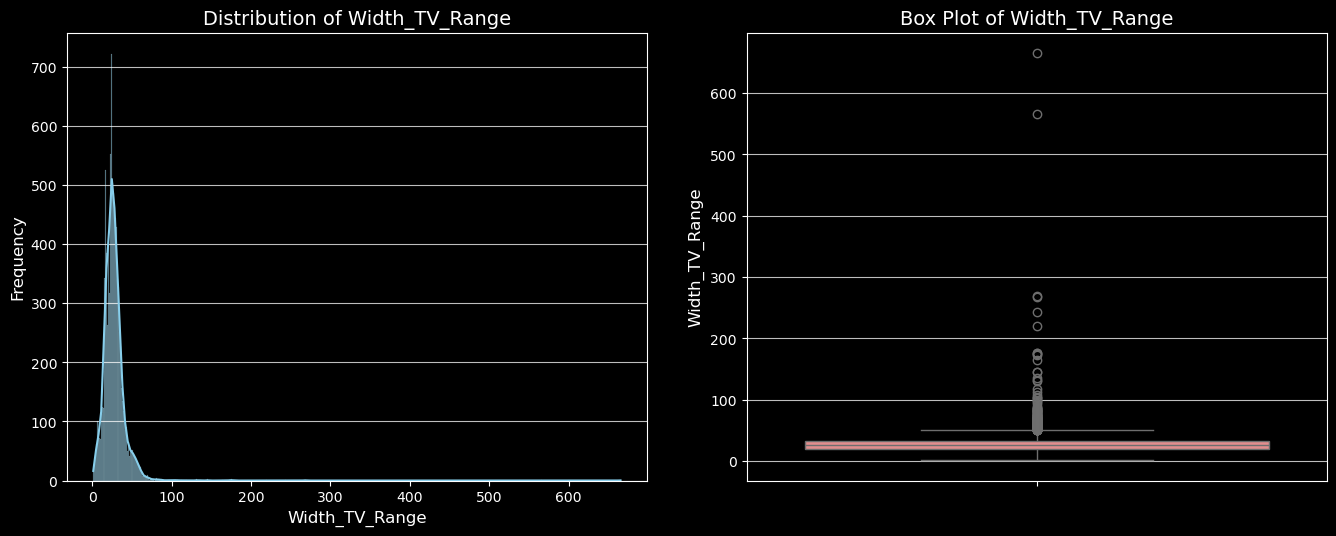


--- Scatter Plots for 'Width_TV_Range' vs. Top Correlated Features ---


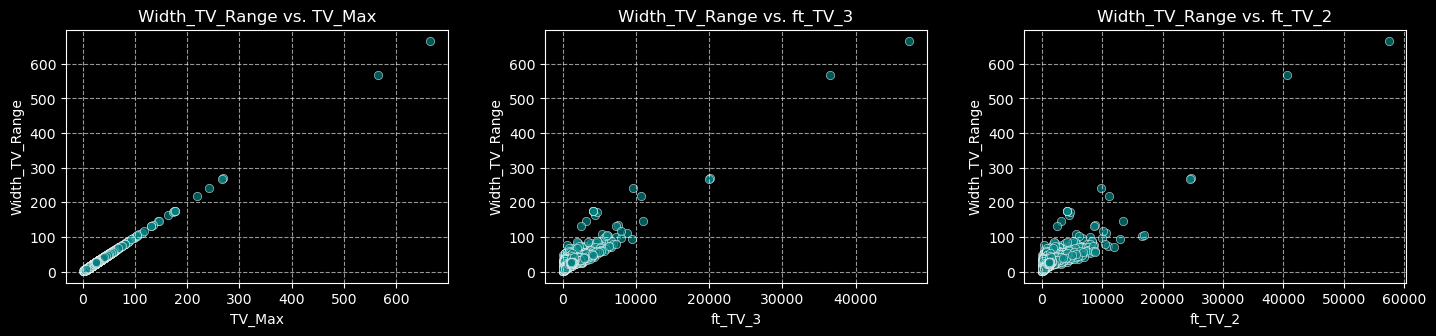


--- Exploring how 'Width_TV_Range' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'Width_TV_Range' by Bins of 'TV_Max' ---

Summary Statistics of 'Width_TV_Range' by 'TV_Max' Bins:
                   count       mean        std      min       25%      50%  \
TV_Max_Binned_Q4                                                             
Q1                2430.0  14.646727   4.282785   1.4336  12.34795  16.4347   
Q2                2430.0  23.159662   1.629011  19.8128  21.83005  23.4440   
Q3                2429.0  28.815059   1.873208  25.6568  27.20540  28.7520   
Q4                2430.0  43.073092  22.345650  32.3586  34.66130  38.2564   

                       75%       max  
TV_Max_Binned_Q4                      
Q1                17.78285   19.8128  
Q2                24.52415   25.6526  
Q3                30.32500   32.3580  
Q4                46.33915  665.3726  


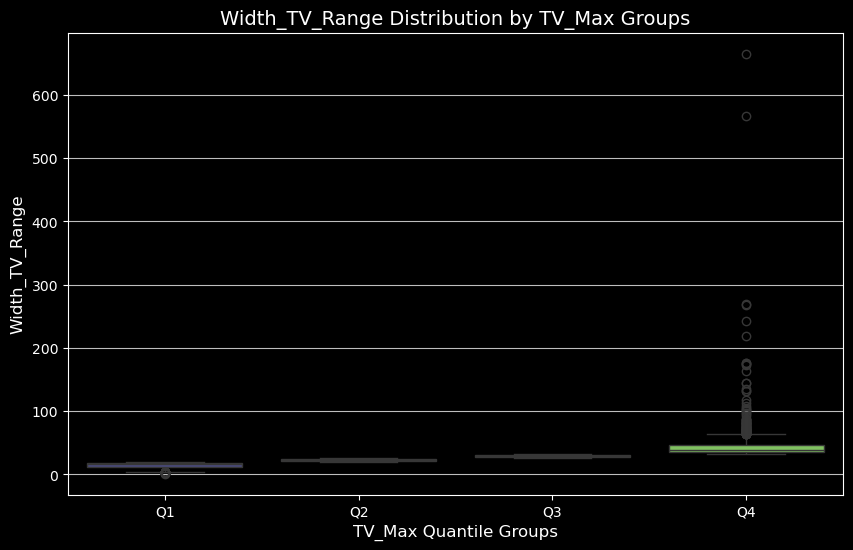

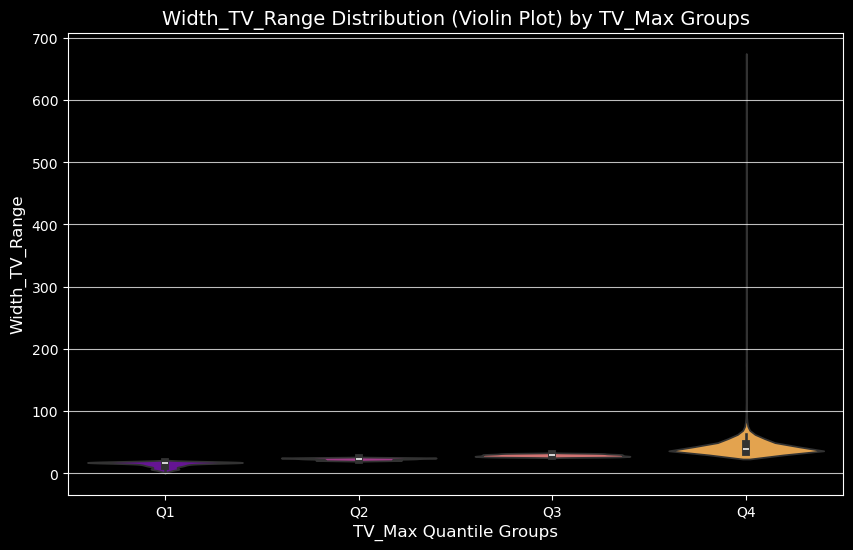


--- Grouped Analysis: 'Width_TV_Range' by Bins of 'ft_TV_3' ---

Summary Statistics of 'Width_TV_Range' by 'ft_TV_3' Bins:
                    count       mean        std      min       25%      50%  \
ft_TV_3_Binned_Q4                                                             
Q1                 2430.0  17.351560   8.023315   1.4336  12.34795  16.7015   
Q2                 2430.0  22.718302   5.393986  12.6602  18.79535  22.5679   
Q3                 2429.0  28.970940   5.156323  17.3804  25.95620  28.4724   
Q4                 2430.0  40.653802  23.045449  22.8382  32.42725  36.3317   

                        75%       max  
ft_TV_3_Binned_Q4                      
Q1                 21.33675   76.3576  
Q2                 24.76965   68.5200  
Q3                 30.67500   68.7586  
Q4                 44.61185  665.3726  


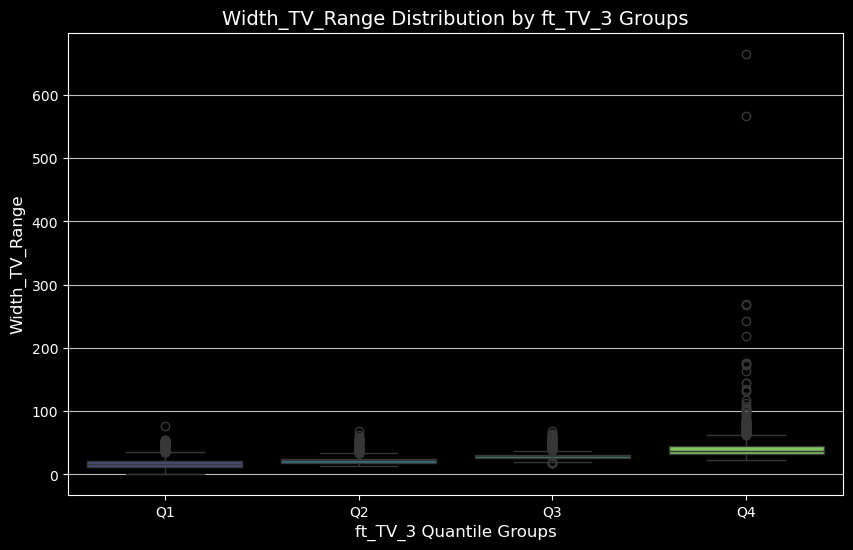

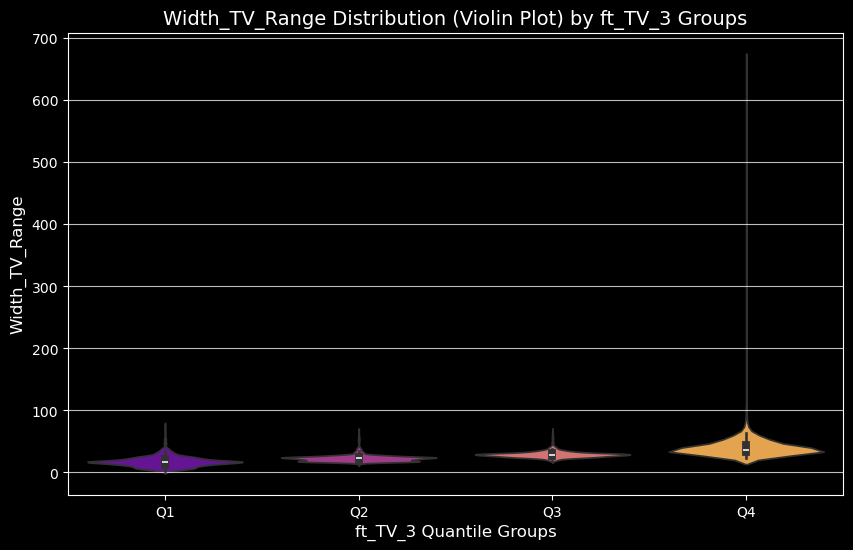


==================== END OF ANALYSIS FOR FEATURE: Width_TV_Range ====================



==================== DETAILED ANALYSIS FOR FEATURE: ft_P_1 ====================

--- Analyzing Feature: 'ft_P_1' ---

Summary Statistics for 'ft_P_1':
count    9719.000000
mean     1879.097886
std       754.729021
min         5.130000
25%      1417.330000
50%      1910.020000
75%      2300.960000
max      8200.400000
Name: ft_P_1, dtype: float64


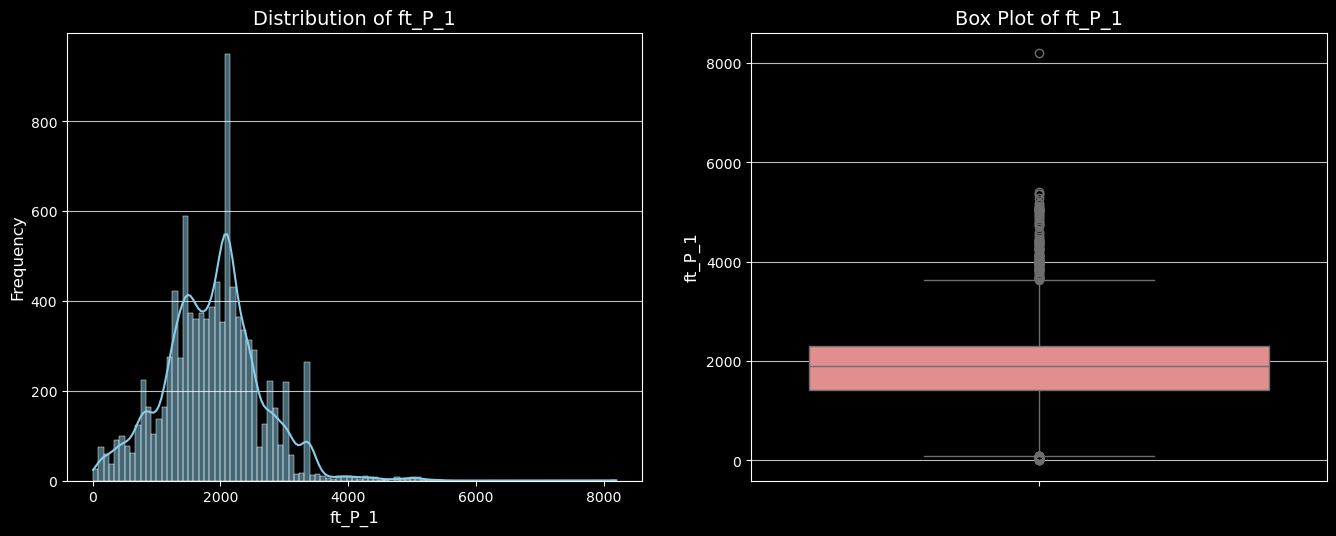


--- Scatter Plots for 'ft_P_1' vs. Top Correlated Features ---


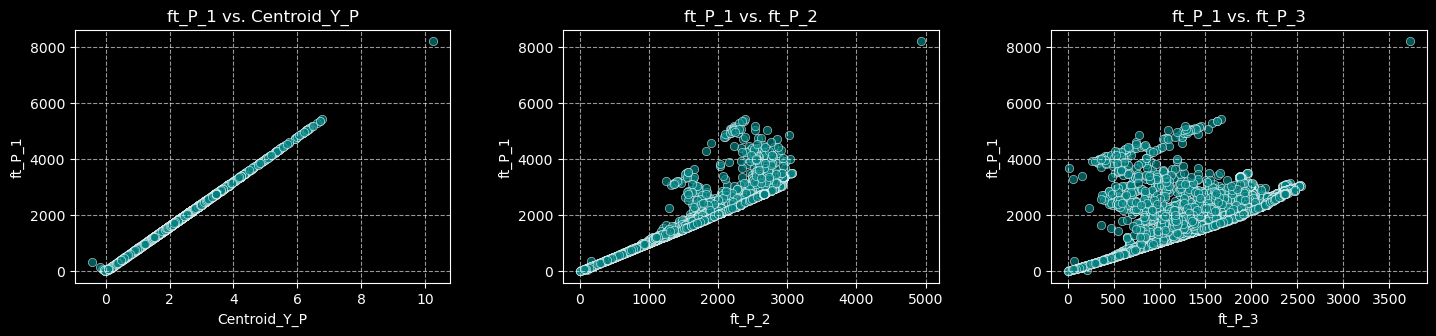


--- Exploring how 'ft_P_1' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'ft_P_1' by Bins of 'Centroid_Y_P' ---

Summary Statistics of 'ft_P_1' by 'Centroid_Y_P' Bins:
                         count         mean         std      min        25%  \
Centroid_Y_P_Binned_Q4                                                        
Q1                      2430.0   949.028576  368.906582     5.13   727.6425   
Q2                      2430.0  1647.045564  149.151711  1417.34  1502.4625   
Q3                      2429.0  2099.894924   99.576917  1910.29  2031.6700   
Q4                      2430.0  2820.513342  506.011913  2301.20  2465.6750   

                             50%        75%      max  
Centroid_Y_P_Binned_Q4                                
Q1                      1051.100  1267.3200  1417.32  
Q2                      1638.955  1779.7850  1910.02  
Q3                      2094.560  2166.0800  2300.72  
Q4                      2726.265  3058.5875  8200

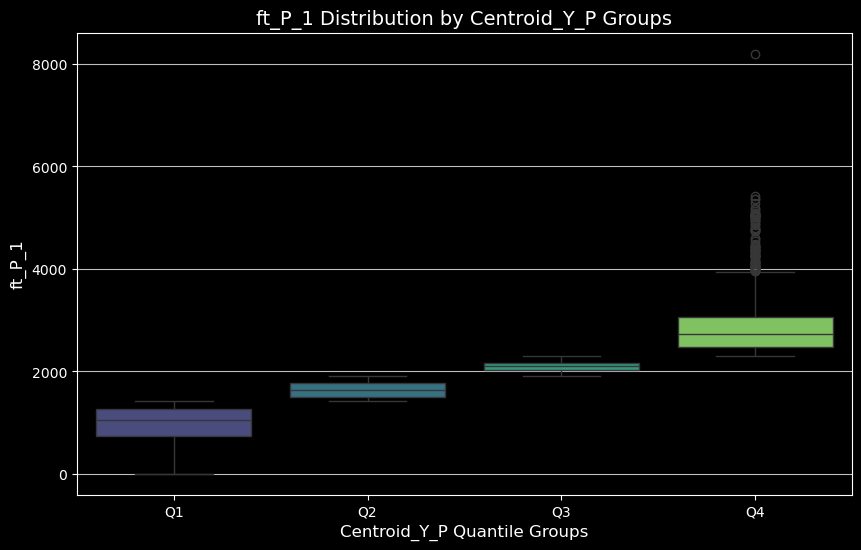

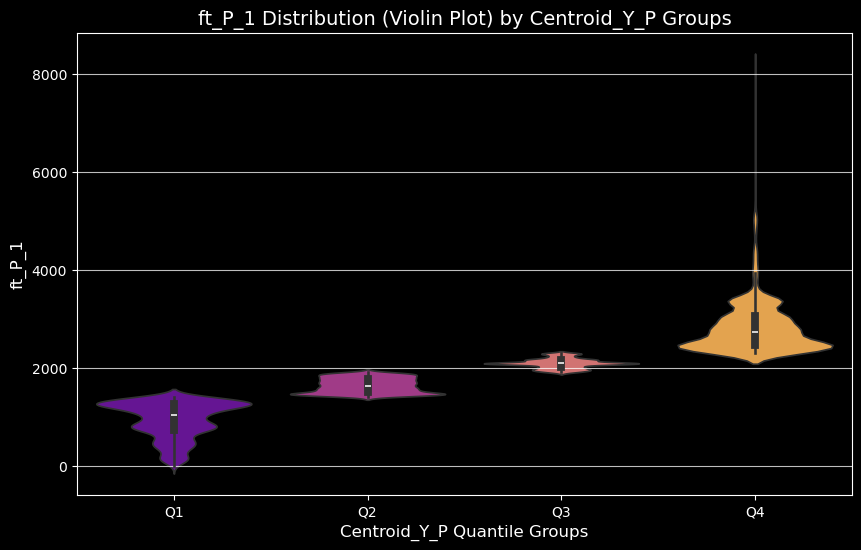


--- Grouped Analysis: 'ft_P_1' by Bins of 'ft_P_2' ---

Summary Statistics of 'ft_P_1' by 'ft_P_2' Bins:
                   count         mean         std      min        25%  \
ft_P_2_Binned_Q4                                                        
Q1                2430.0   953.579407  381.434633     5.13   727.6425   
Q2                2430.0  1678.641568  251.448454  1368.03  1501.0875   
Q3                2429.0  2093.257196  199.385091  1797.11  2001.1400   
Q4                2430.0  2791.001502  505.534066  2184.96  2450.7750   

                       50%      75%      max  
ft_P_2_Binned_Q4                              
Q1                1051.100  1267.32  3226.42  
Q2                1636.740  1779.00  3656.36  
Q3                2091.910  2160.90  4885.58  
Q4                2681.175  3057.07  8200.40  


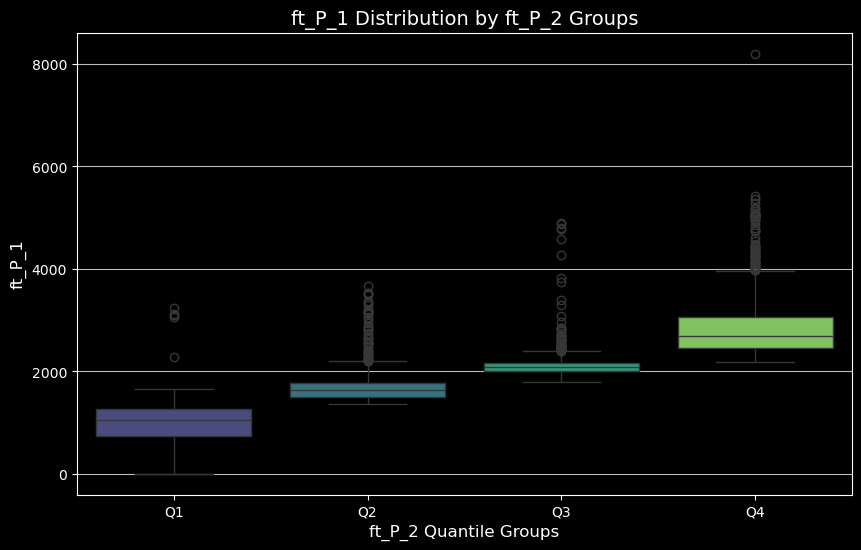

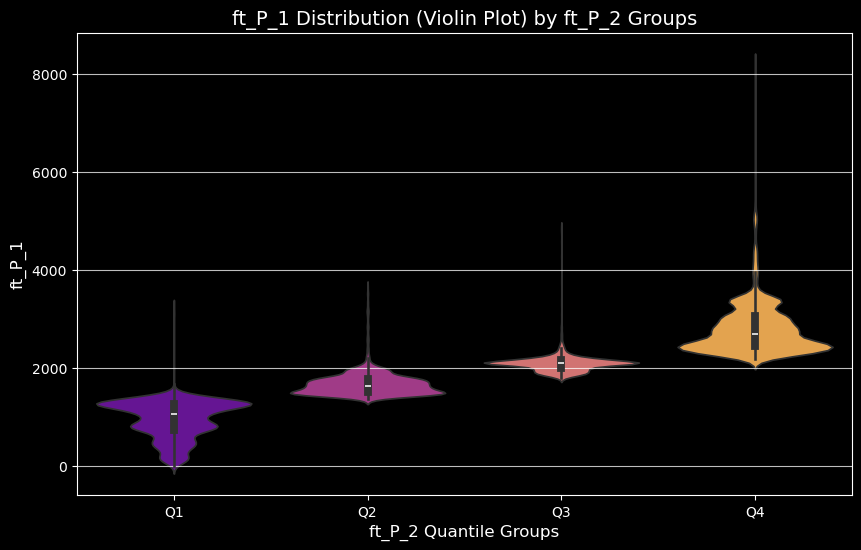


==================== END OF ANALYSIS FOR FEATURE: ft_P_1 ====================



==================== DETAILED ANALYSIS FOR FEATURE: ft_P_2 ====================

--- Analyzing Feature: 'ft_P_2' ---

Summary Statistics for 'ft_P_2':
count    9719.000000
mean     1738.337940
std       623.490819
min         5.467343
25%      1359.703298
50%      1773.847047
75%      2147.392360
max      4939.818792
Name: ft_P_2, dtype: float64


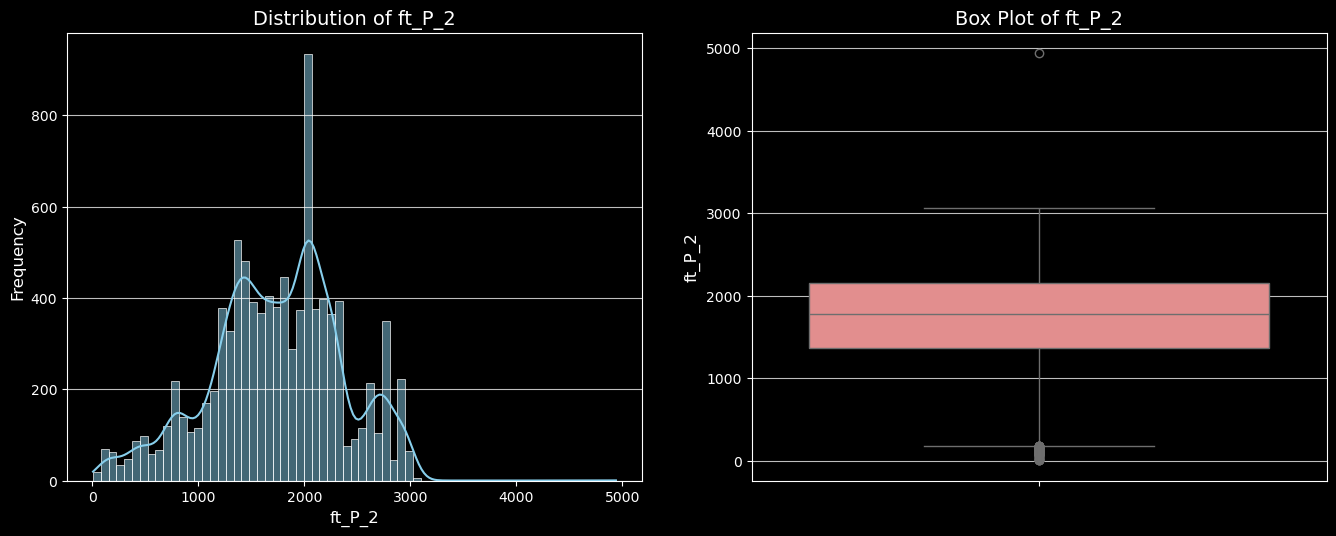


--- Scatter Plots for 'ft_P_2' vs. Top Correlated Features ---


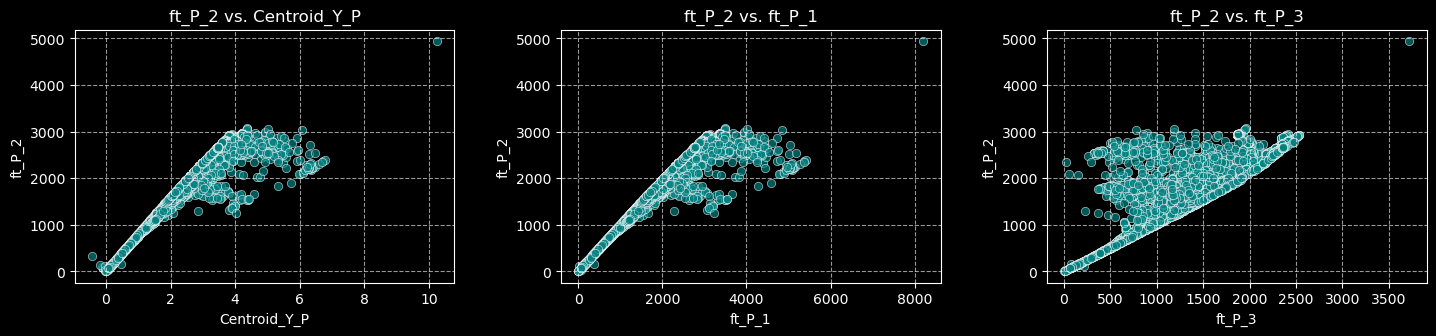


--- Exploring how 'ft_P_2' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'ft_P_2' by Bins of 'Centroid_Y_P' ---

Summary Statistics of 'ft_P_2' by 'Centroid_Y_P' Bins:
                         count         mean         std          min  \
Centroid_Y_P_Binned_Q4                                                 
Q1                      2430.0   928.030058  356.050973     5.467343   
Q2                      2430.0  1565.407643  145.087232  1176.359185   
Q3                      2429.0  1985.073488  139.319738  1288.585313   
Q4                      2430.0  2474.942109  312.385654  1252.733760   

                                25%          50%          75%          max  
Centroid_Y_P_Binned_Q4                                                      
Q1                       718.610601  1023.700267  1242.658490  1406.591804  
Q2                      1438.558776  1543.670597  1681.263694  1881.017787  
Q3                      1910.511580  2021.672164  2052.460

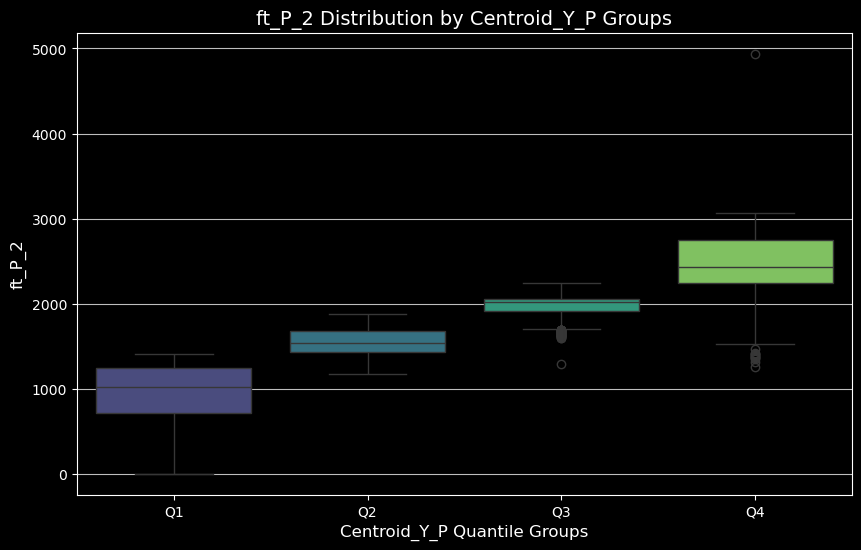

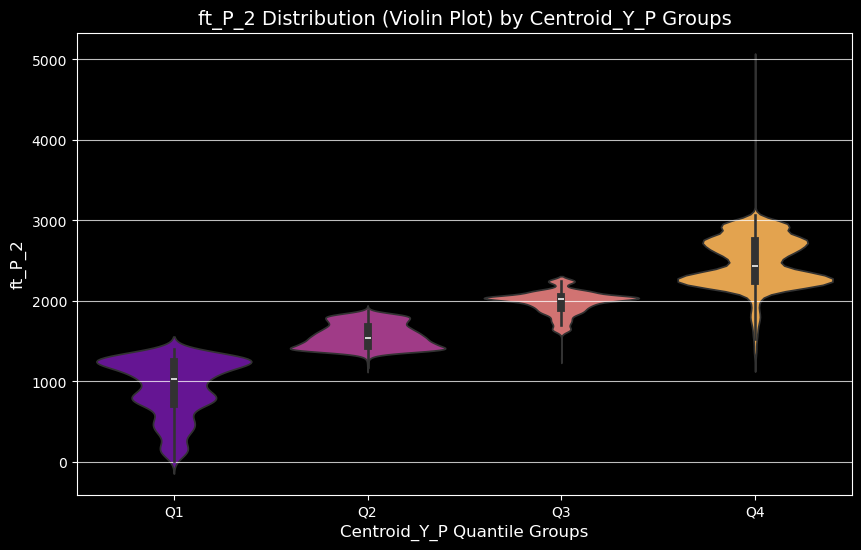


--- Grouped Analysis: 'ft_P_2' by Bins of 'ft_P_1' ---

Summary Statistics of 'ft_P_2' by 'ft_P_1' Bins:
                   count         mean         std          min          25%  \
ft_P_1_Binned_Q4                                                              
Q1                2430.0   928.030058  356.050973     5.467343   718.610601   
Q2                2430.0  1565.407643  145.087232  1176.359185  1438.558776   
Q3                2429.0  1985.073488  139.319738  1288.585313  1910.511580   
Q4                2430.0  2474.942109  312.385654  1252.733760  2240.484429   

                          50%          75%          max  
ft_P_1_Binned_Q4                                         
Q1                1023.700267  1242.658490  1406.591804  
Q2                1543.670597  1681.263694  1881.017787  
Q3                2021.672164  2052.460345  2247.545113  
Q4                2431.683844  2748.377940  4939.818792  


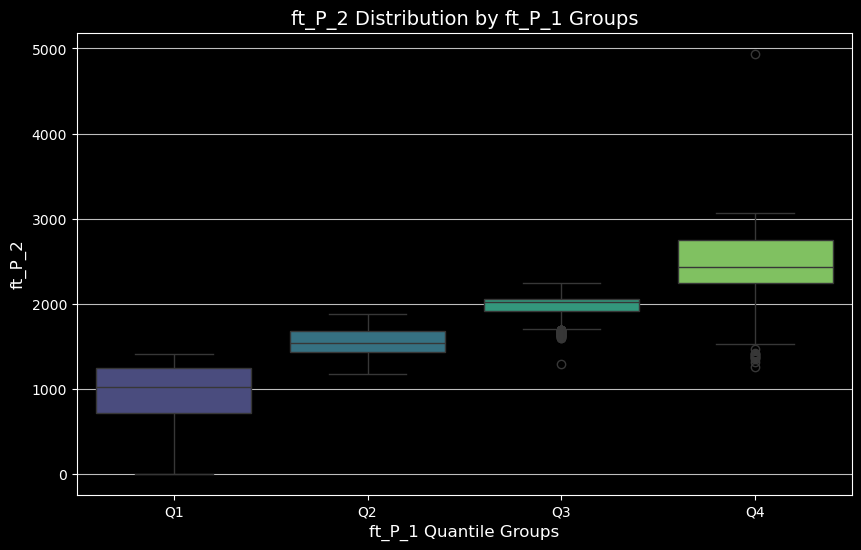

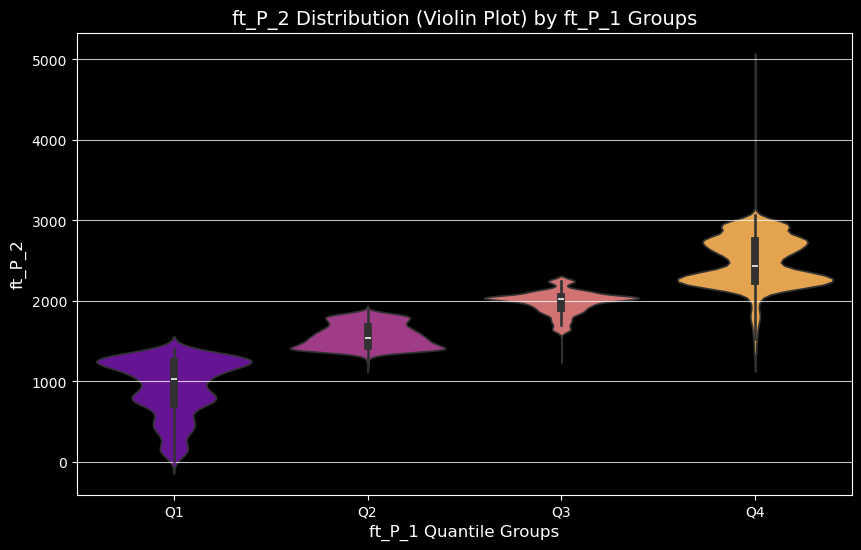


==================== END OF ANALYSIS FOR FEATURE: ft_P_2 ====================



==================== DETAILED ANALYSIS FOR FEATURE: ft_P_3 ====================

--- Analyzing Feature: 'ft_P_3' ---

Summary Statistics for 'ft_P_3':
count    9719.000000
mean     1425.723758
std       502.115659
min         6.381168
25%      1096.919480
50%      1447.790355
75%      1824.899531
max      3721.769443
Name: ft_P_3, dtype: float64


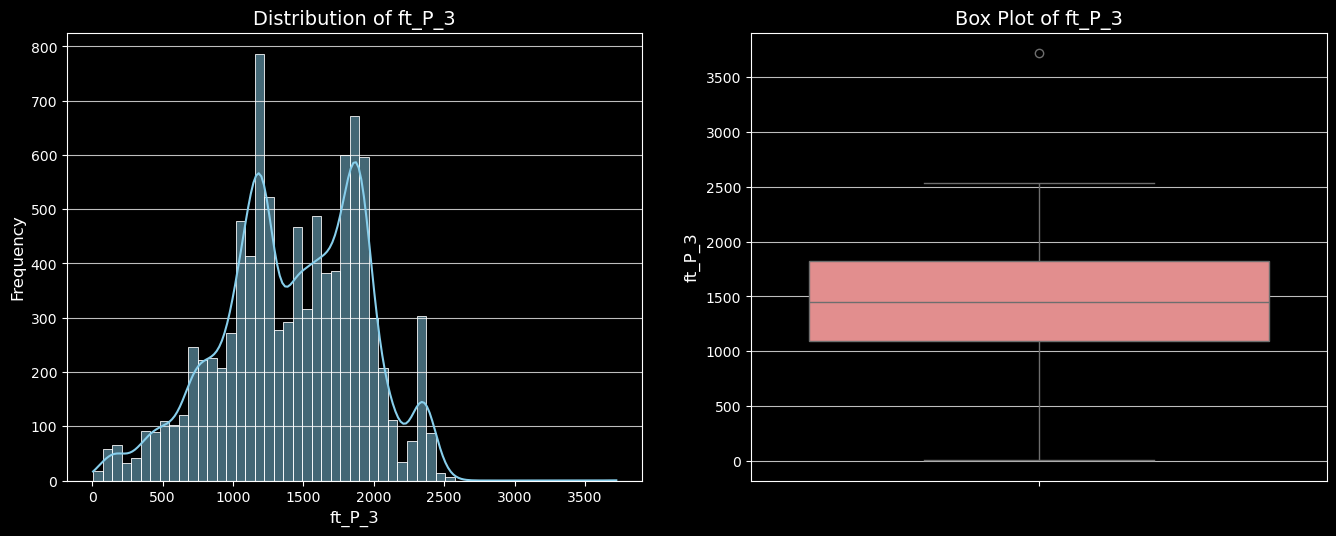


--- Scatter Plots for 'ft_P_3' vs. Top Correlated Features ---


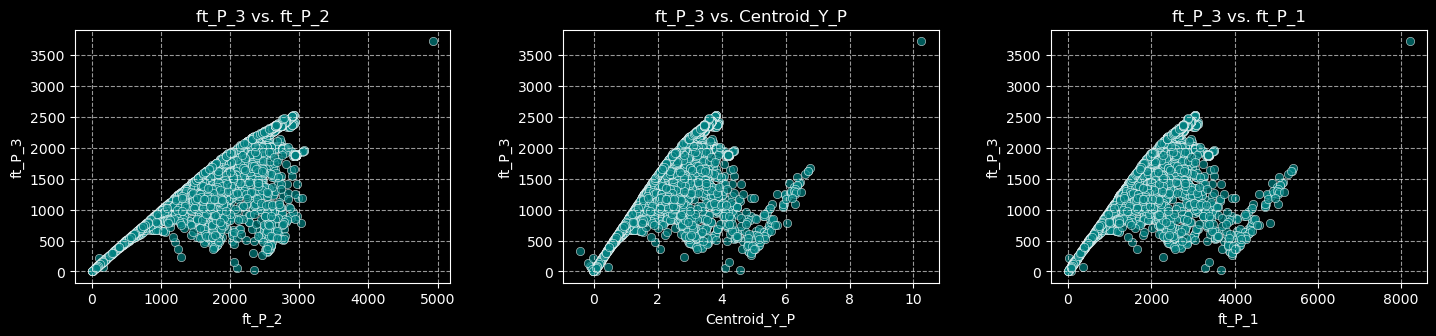


--- Exploring how 'ft_P_3' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'ft_P_3' by Bins of 'ft_P_2' ---

Summary Statistics of 'ft_P_3' by 'ft_P_2' Bins:
                   count         mean         std         min          25%  \
ft_P_2_Binned_Q4                                                             
Q1                2430.0   860.094654  318.673756    6.381168   683.202787   
Q2                2430.0  1266.049819  223.926233  364.786945  1146.827321   
Q3                2429.0  1691.085966  256.005904   56.677039  1608.162902   
Q4                2430.0  1885.773794  404.667318   19.792429  1800.826658   

                          50%          75%          max  
ft_P_2_Binned_Q4                                         
Q1                 931.706800  1128.371917  1329.469525  
Q2                1244.829998  1435.686594  1717.507864  
Q3                1733.302741  1880.607283  2023.558844  
Q4                1899.404473  2108.446680  3721.769

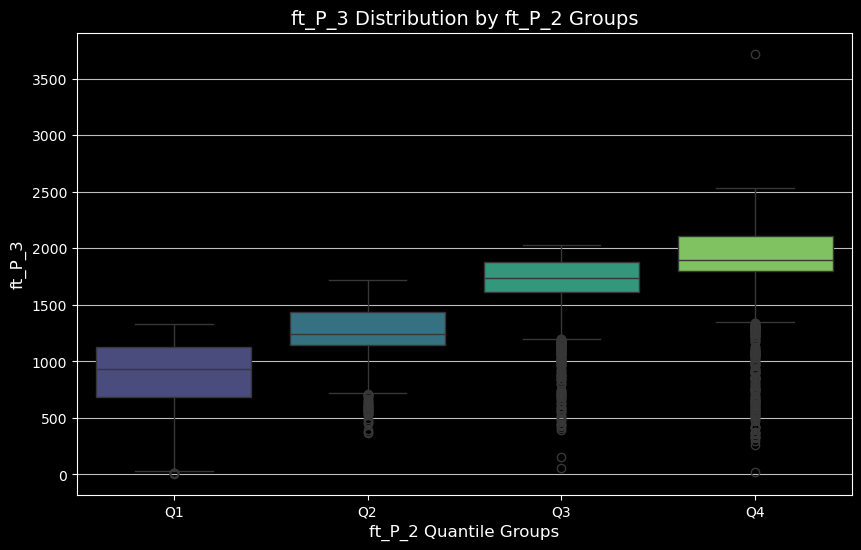

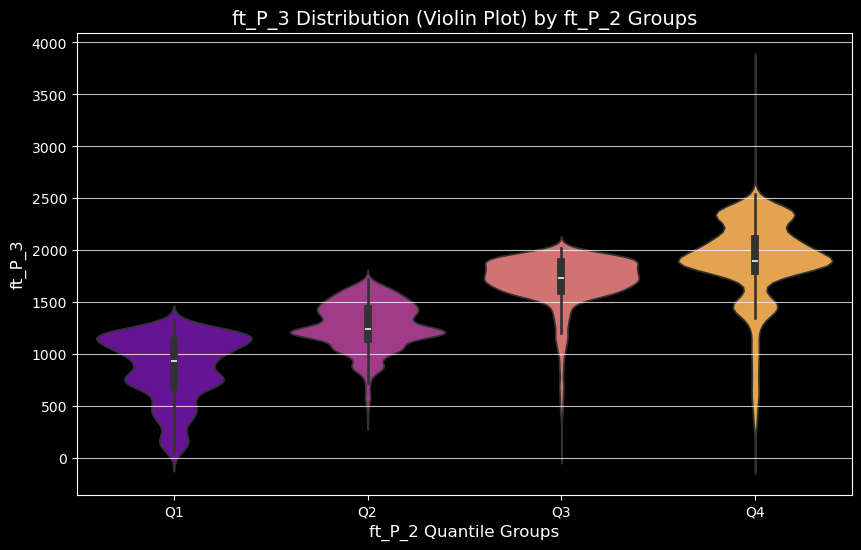


--- Grouped Analysis: 'ft_P_3' by Bins of 'Centroid_Y_P' ---

Summary Statistics of 'ft_P_3' by 'Centroid_Y_P' Bins:
                         count         mean         std         min  \
Centroid_Y_P_Binned_Q4                                                
Q1                      2430.0   868.512783  325.063930    6.381168   
Q2                      2430.0  1345.069962  215.366095  365.460798   
Q3                      2429.0  1685.098698  313.693844  233.349036   
Q4                      2430.0  1804.320327  480.089954   19.792429   

                                25%          50%          75%          max  
Centroid_Y_P_Binned_Q4                                                      
Q1                       684.555811   936.539532  1149.544861  1378.510756  
Q2                      1186.791144  1340.616452  1528.258011  1825.181943  
Q3                      1605.225074  1776.559900  1898.680379  2093.138513  
Q4                      1552.106409  1884.500241  2108.446680  3721.76

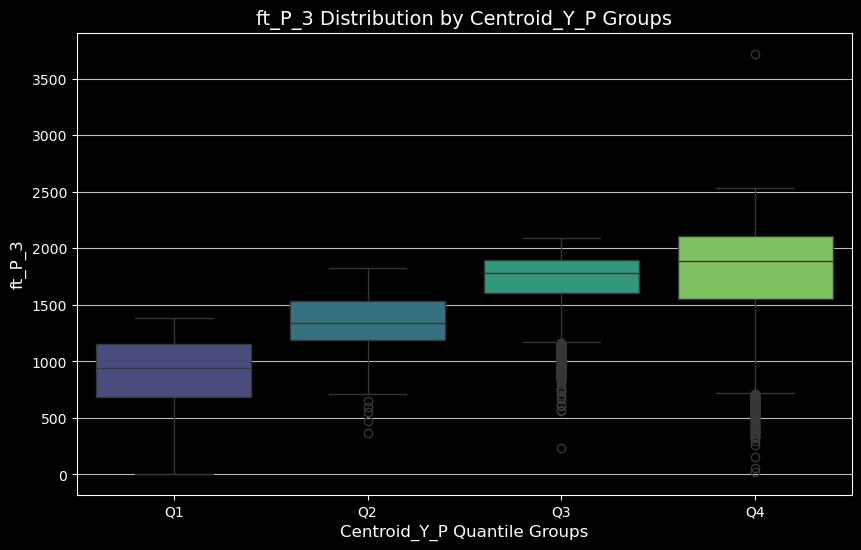

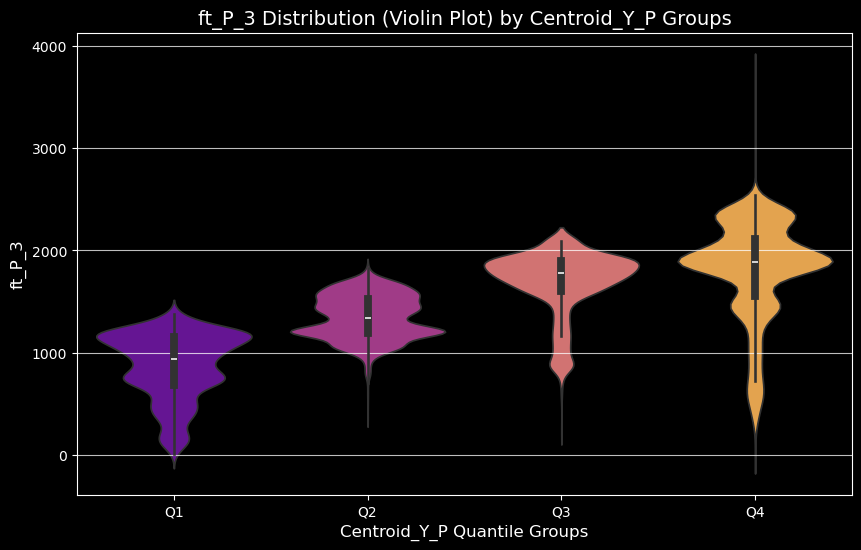


==================== END OF ANALYSIS FOR FEATURE: ft_P_3 ====================



==================== DETAILED ANALYSIS FOR FEATURE: ft_TV_1 ====================

--- Analyzing Feature: 'ft_TV_1' ---

Summary Statistics for 'ft_TV_1':
count      9719.000000
mean       4137.022613
std        9378.168188
min          46.236400
25%        1354.021400
50%        2029.927200
75%        4128.283000
max      463162.764400
Name: ft_TV_1, dtype: float64


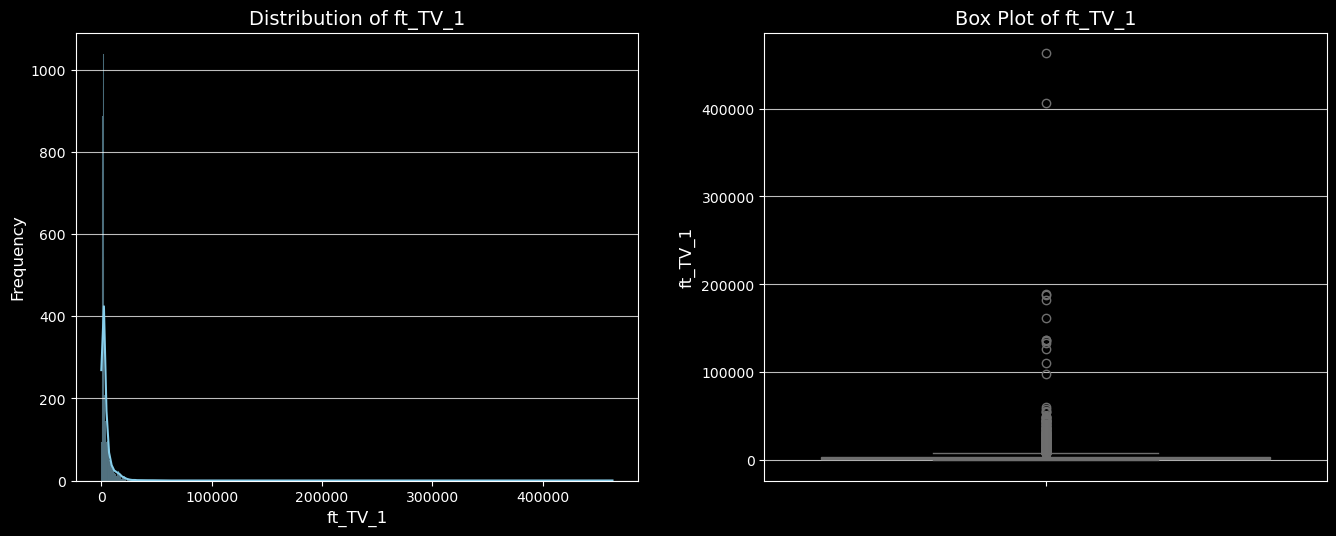


--- Scatter Plots for 'ft_TV_1' vs. Top Correlated Features ---


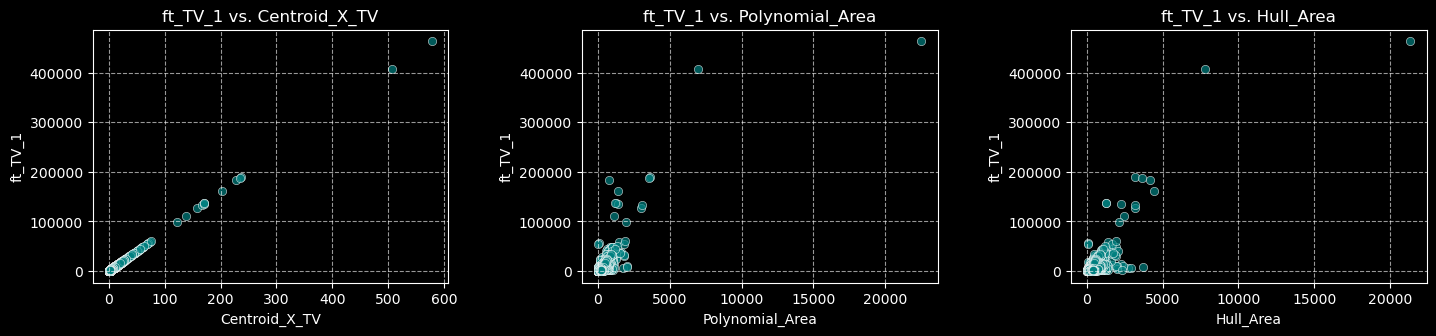


--- Exploring how 'ft_TV_1' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'ft_TV_1' by Bins of 'Centroid_X_TV' ---

Summary Statistics of 'ft_TV_1' by 'Centroid_X_TV' Bins:
                          count          mean           std        min  \
Centroid_X_TV_Binned_Q4                                                  
Q1                       2430.0    941.025852    280.177739    46.2364   
Q2                       2430.0   1700.664725    204.794520  1354.0388   
Q3                       2429.0   2769.078333    599.498953  2030.6194   
Q4                       2430.0  11136.758603  16862.628759  4129.8138   

                                25%        50%          75%          max  
Centroid_X_TV_Binned_Q4                                                   
Q1                        793.00095   969.0959   1165.62410    1354.0040  
Q2                       1509.31115  1709.8949   1894.23450    2029.9272  
Q3                       2258.86320  2609.9684   

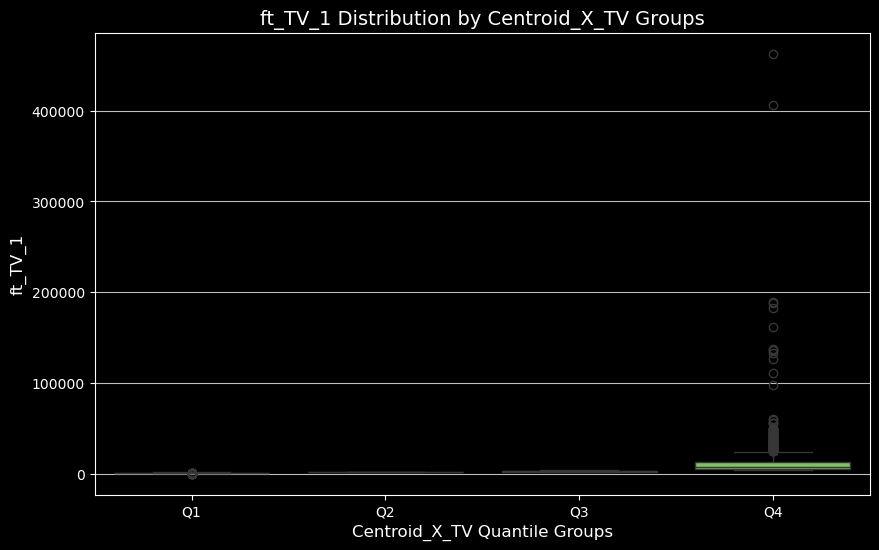

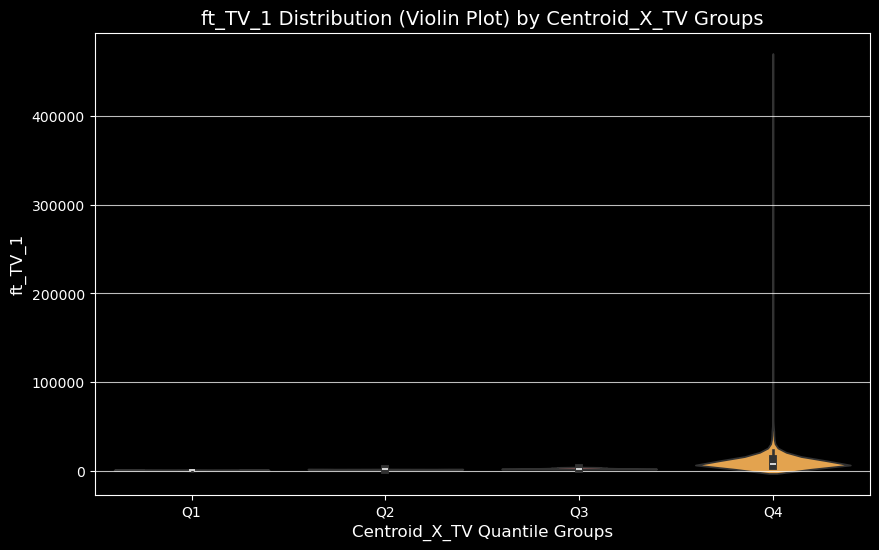


--- Grouped Analysis: 'ft_TV_1' by Bins of 'Polynomial_Area' ---

Summary Statistics of 'ft_TV_1' by 'Polynomial_Area' Bins:
                            count         mean           std       min  \
Polynomial_Area_Binned_Q4                                                
Q1                         2430.0  2002.365804   2416.375207   46.2364   
Q2                         2430.0  2257.852785   1938.394200   46.5472   
Q3                         2429.0  2915.647818   2592.355353  675.4670   
Q4                         2430.0  9371.721422  17278.955761  506.5496   

                                  25%        50%         75%          max  
Polynomial_Area_Binned_Q4                                                  
Q1                          892.94645  1337.1897   2249.9397   55958.1868  
Q2                         1132.26115  1801.7285   2437.2995   22466.4834  
Q3                         1505.67240  1989.8082   3020.0804   27453.7824  
Q4                         2686.09910  5673.3808 

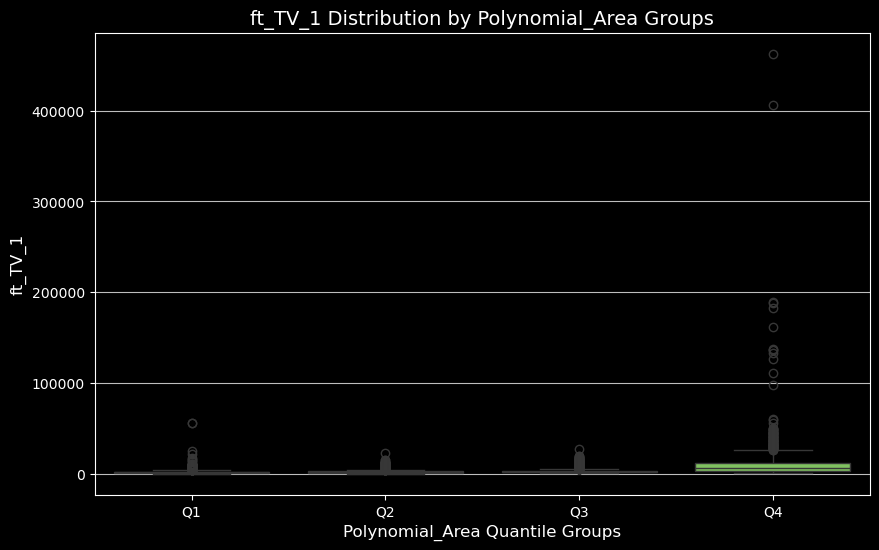

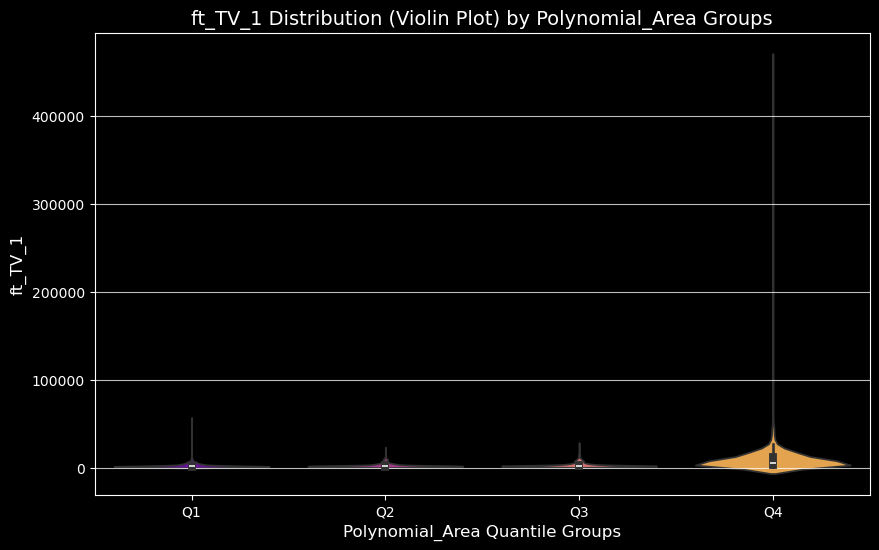


==================== END OF ANALYSIS FOR FEATURE: ft_TV_1 ====================



==================== DETAILED ANALYSIS FOR FEATURE: ft_TV_2 ====================

--- Analyzing Feature: 'ft_TV_2' ---

Summary Statistics for 'ft_TV_2':
count     9719.000000
mean      1427.637205
std       1371.714901
min          0.923681
25%        777.487464
50%       1235.469412
75%       1779.301403
max      57384.868568
Name: ft_TV_2, dtype: float64


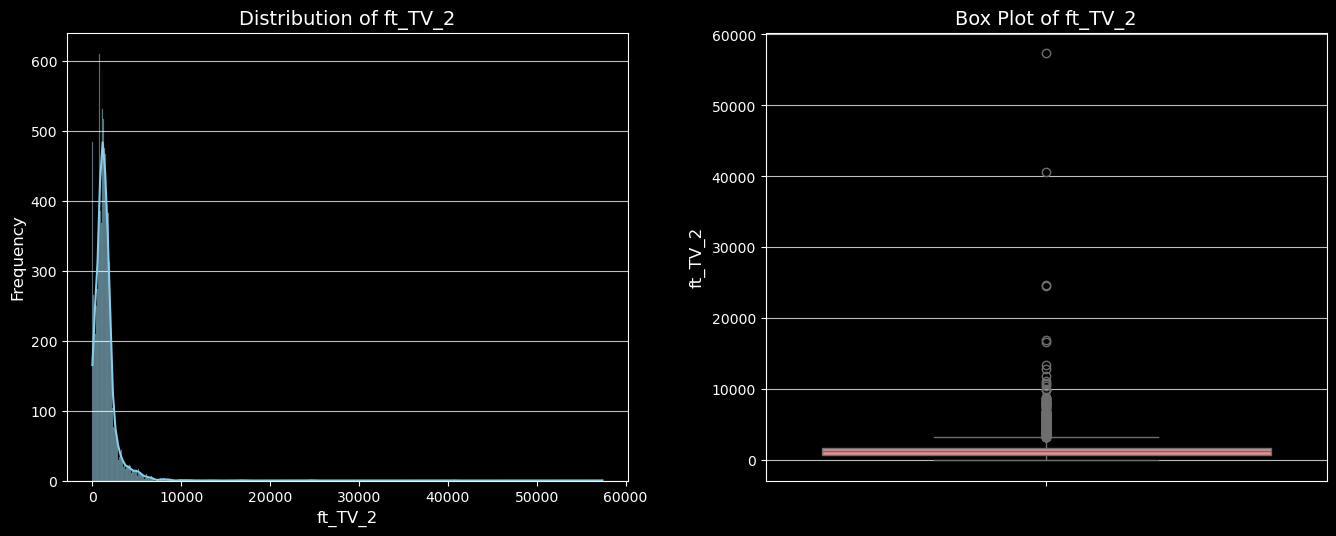


--- Scatter Plots for 'ft_TV_2' vs. Top Correlated Features ---


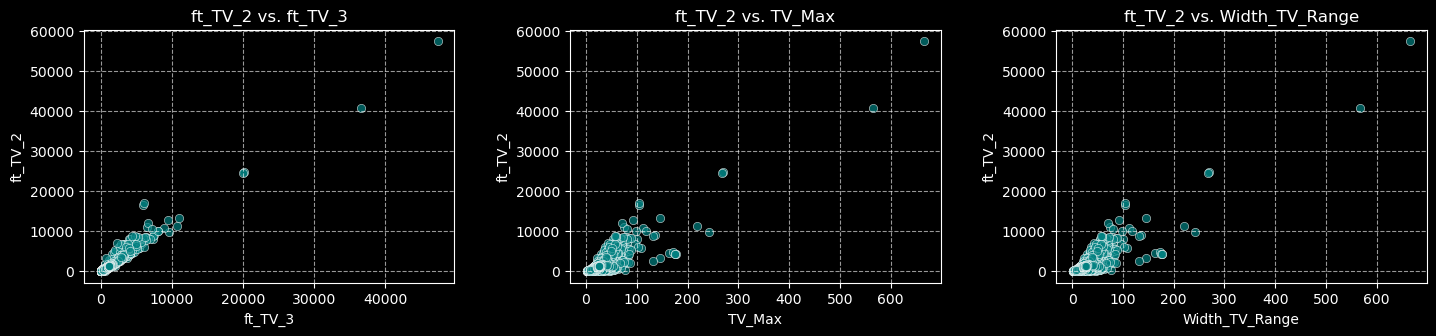


--- Exploring how 'ft_TV_2' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'ft_TV_2' by Bins of 'ft_TV_3' ---

Summary Statistics of 'ft_TV_2' by 'ft_TV_3' Bins:
                    count         mean          std          min          25%  \
ft_TV_3_Binned_Q4                                                               
Q1                 2430.0   378.466921   262.937209     0.923681   139.240844   
Q2                 2430.0  1010.816722   151.423801   415.307123   872.787985   
Q3                 2429.0  1484.330938   181.101796  1059.535698  1345.379598   
Q4                 2430.0  2836.957571  2034.175210  1178.351257  1936.237063   

                           50%          75%           max  
ft_TV_3_Binned_Q4                                          
Q1                  380.698135   612.343667   3233.715025  
Q2                 1028.685844  1126.650696   2660.132243  
Q3                 1463.974990  1608.831709   4189.827394  
Q4                 

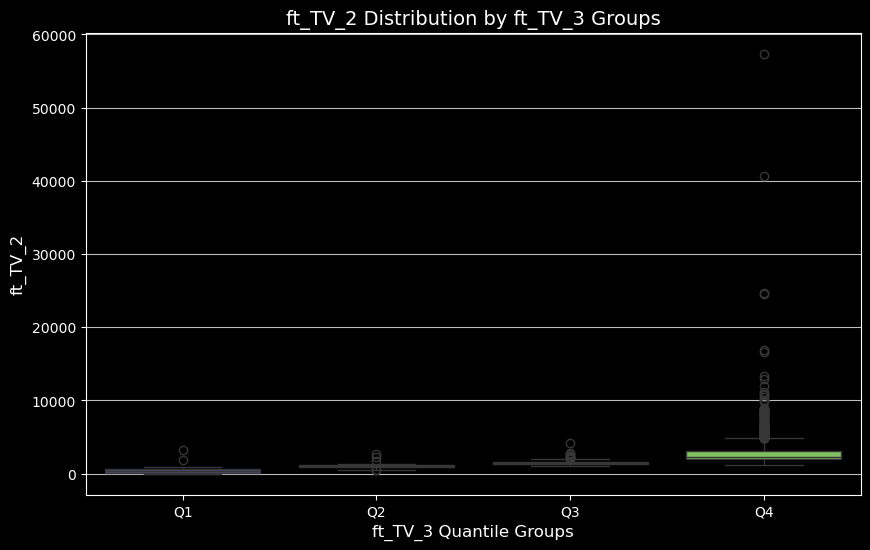

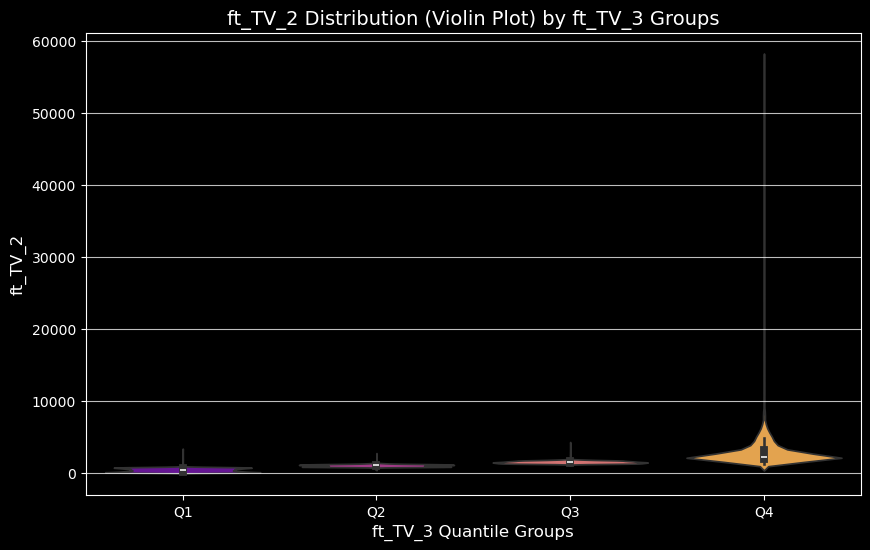


--- Grouped Analysis: 'ft_TV_2' by Bins of 'TV_Max' ---

Summary Statistics of 'ft_TV_2' by 'TV_Max' Bins:
                   count         mean          std        min          25%  \
TV_Max_Binned_Q4                                                             
Q1                2430.0   540.289722   363.833185   0.923681   177.573738   
Q2                2430.0  1075.991622   436.681456  38.064822   848.402168   
Q3                2429.0  1443.997269   446.201494  53.629090  1249.635052   
Q4                2430.0  2650.276941  2144.465209  39.203591  1741.525168   

                          50%          75%           max  
TV_Max_Binned_Q4                                          
Q1                 597.929040   814.292754   1669.131856  
Q2                1086.329501  1303.594004   3311.013390  
Q3                1476.430321  1699.268856   4189.827394  
Q4                2172.026106  3076.988344  57384.868568  


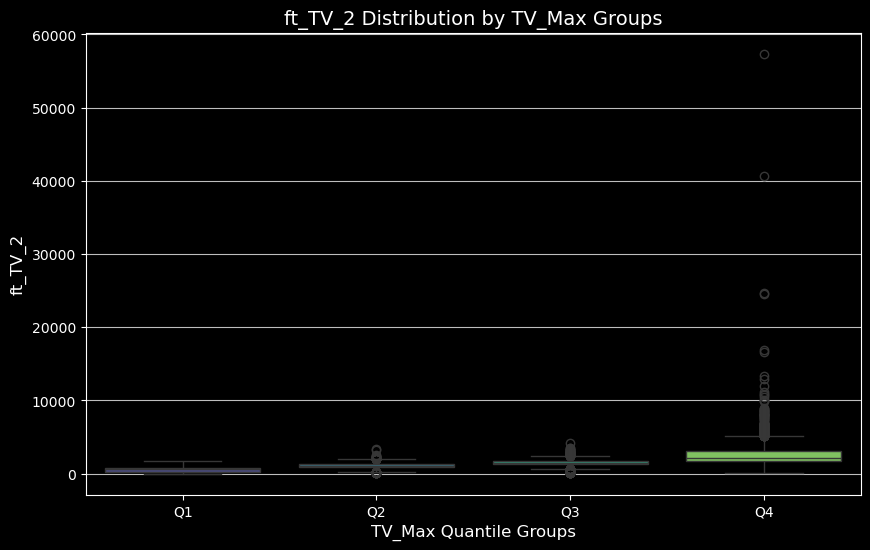

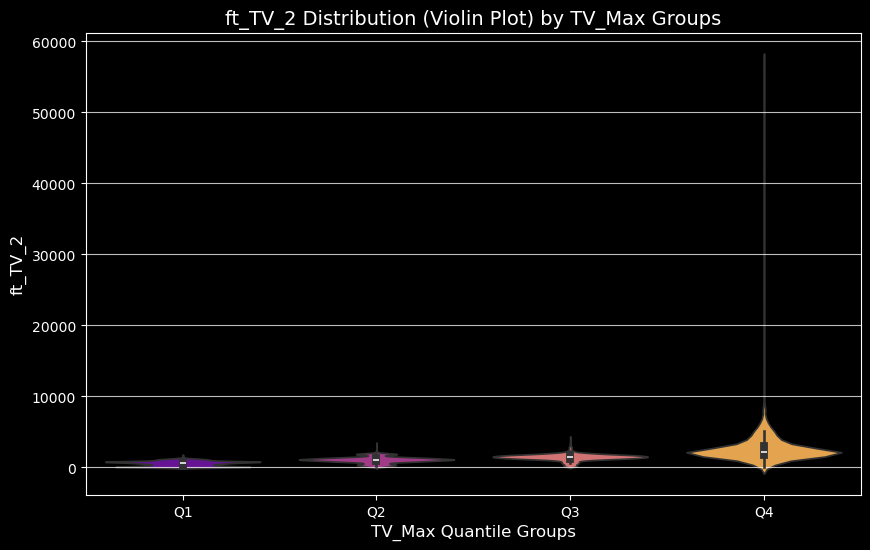


==================== END OF ANALYSIS FOR FEATURE: ft_TV_2 ====================



==================== DETAILED ANALYSIS FOR FEATURE: ft_TV_3 ====================

--- Analyzing Feature: 'ft_TV_3' ---

Summary Statistics for 'ft_TV_3':
count     9719.000000
mean      1274.259501
std       1066.066103
min          1.114634
25%        750.628496
50%       1162.756770
75%       1635.419999
max      47348.649963
Name: ft_TV_3, dtype: float64


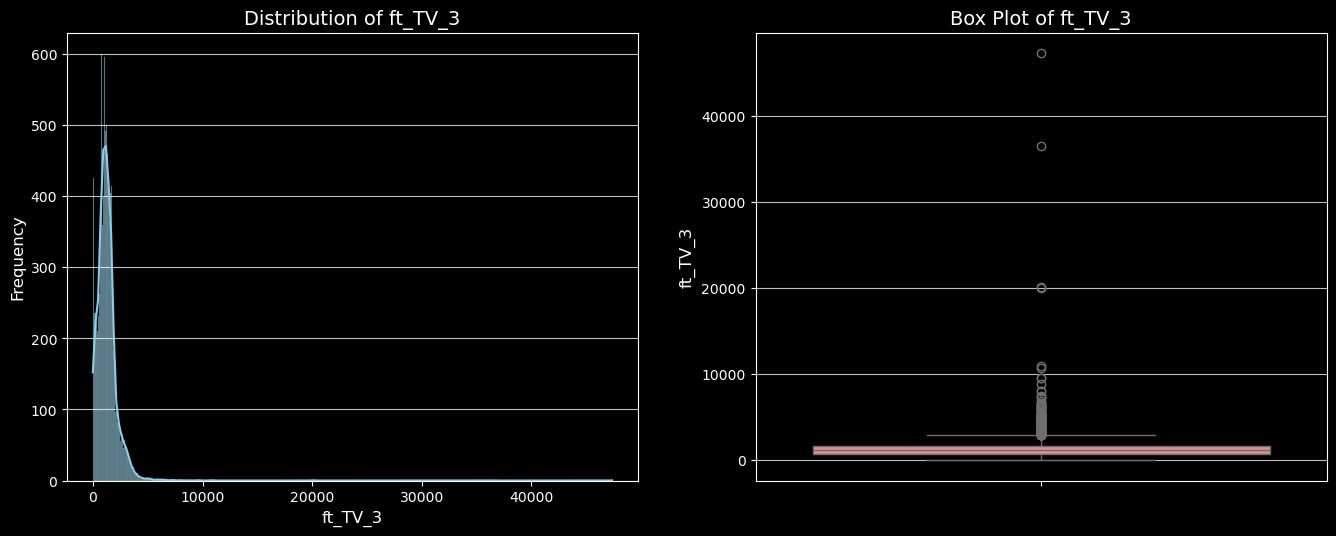


--- Scatter Plots for 'ft_TV_3' vs. Top Correlated Features ---


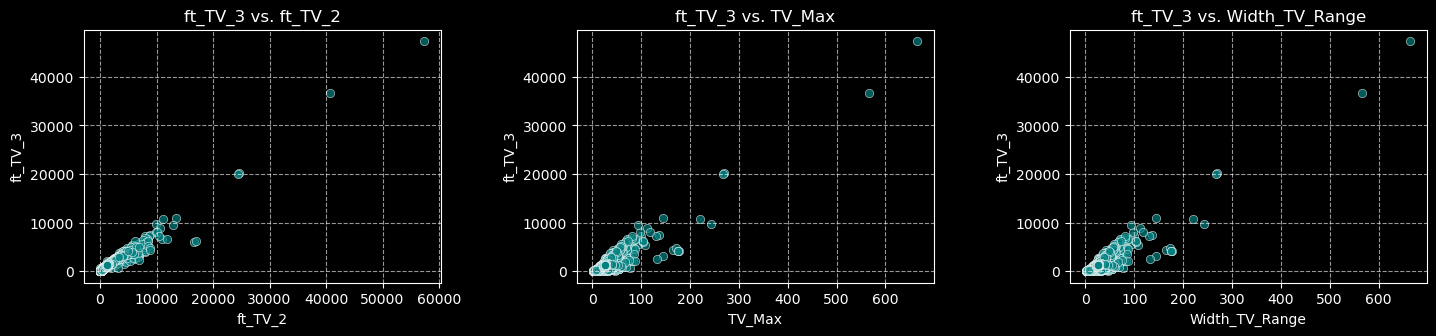


--- Exploring how 'ft_TV_3' is influenced by other features (Grouped Analysis) ---

--- Grouped Analysis: 'ft_TV_3' by Bins of 'ft_TV_2' ---

Summary Statistics of 'ft_TV_3' by 'ft_TV_2' Bins:
                    count         mean          std         min          25%  \
ft_TV_2_Binned_Q4                                                              
Q1                 2430.0   375.651854   245.690038    1.114634   152.025622   
Q2                 2430.0   960.845394   130.214004  707.534275   836.877656   
Q3                 2429.0  1388.665217   147.616262  999.596371  1265.074310   
Q4                 2430.0  2371.922619  1524.229852  595.733229  1761.605999   

                           50%          75%           max  
ft_TV_2_Binned_Q4                                          
Q1                  382.433815   599.910823   1089.799566  
Q2                  974.392129  1063.821225   2064.929667  
Q3                 1382.435448  1505.152375   1824.150282  
Q4                 2018.4

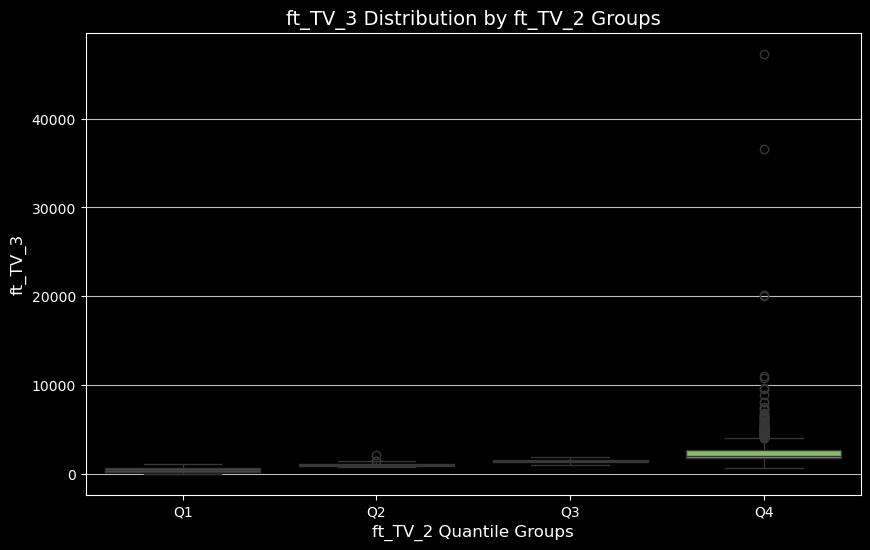

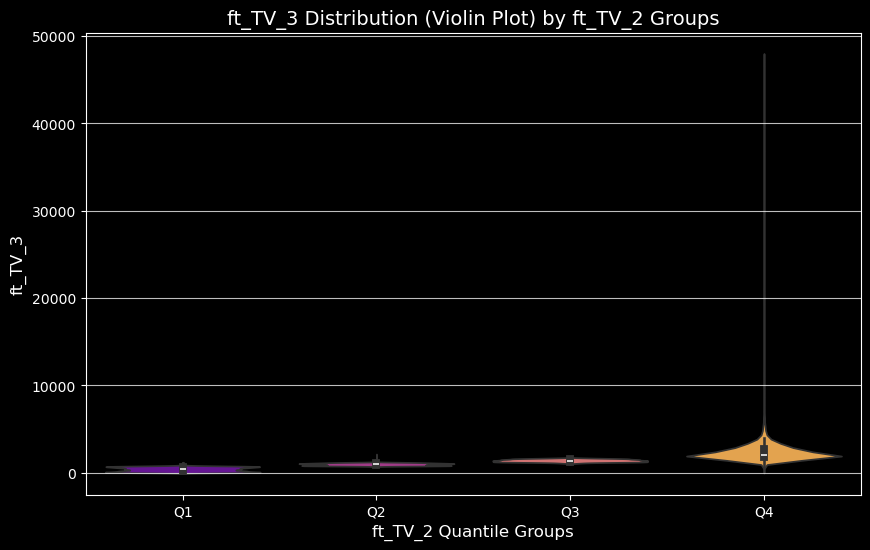


--- Grouped Analysis: 'ft_TV_3' by Bins of 'TV_Max' ---

Summary Statistics of 'ft_TV_3' by 'TV_Max' Bins:
                   count         mean          std        min          25%  \
TV_Max_Binned_Q4                                                             
Q1                2430.0   515.717184   337.329393   1.114634   177.637578   
Q2                2430.0  1002.788511   374.719458  48.974914   821.227974   
Q3                2429.0  1346.252047   369.414862  68.721297  1197.748721   
Q4                2430.0  2232.309888  1607.337878  76.659451  1638.321682   

                          50%          75%           max  
TV_Max_Binned_Q4                                          
Q1                 577.640190   779.440995   1276.589575  
Q2                1031.863057  1194.609468   2612.713864  
Q3                1391.880207  1575.752188   2805.828247  
Q4                1990.716067  2653.315299  47348.649963  


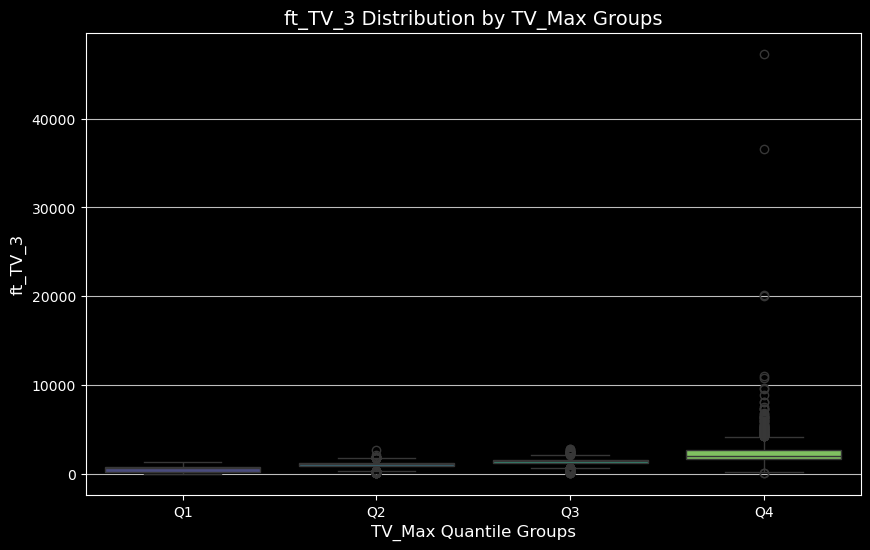

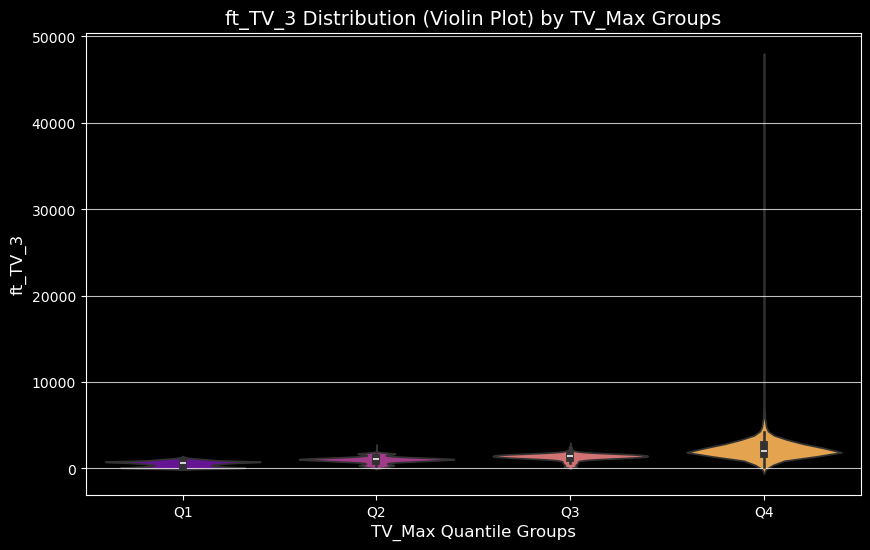


==================== END OF ANALYSIS FOR FEATURE: ft_TV_3 ====================



--- All EDA Complete ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9719 entries, 0 to 9718
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Aspect_Ratio_H_W  9719 non-null   float64
 1   Centroid_X_TV     9719 non-null   float64
 2   Centroid_Y_P      9719 non-null   float64
 3   Height_P_Range    9719 non-null   float64
 4   Hull_Area         9719 non-null   float64
 5   P_Max             9719 non-null   float64
 6   Perimeter         9719 non-null   float64
 7   Polynomial_Area   9719 non-null   float64
 8   TV_Max            9719 non-null   float64
 9   Width_TV_Range    9719 non-null   float64
 10  ft_P_1            9719 non-null   float64
 11  ft_P_2            9719 non-null   float64
 12  ft_P_3            9719 non-null   float64
 13  ft_TV_1           9719 non-null   float64
 14  ft_TV_2           9719 non-n

In [63]:
dataset = EDA(dataset) #Exploratory Data Analysis
dataset.to_csv("Static_FeatureExtract.csv")
dataset.info()